<a class="anchor" id="0">

# **0. Setup & Imports**

[Back to TOC](#toc)
</a>


In [1]:
%pip install wordcloud nltk  
%pip install xgboost
%pip install transformers
%pip install torch
%pip install sentencepiece
%pip install tokenizers

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import warnings
from collections import Counter
from typing import List, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pickle
import json
import os
from datetime import datetime

# NLTK for NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Scikit-learn for traditional ML and preprocessing
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, 
    confusion_matrix, precision_recall_fscore_support
)
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight

# Traditional ML Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
import xgboost as xgb

# Word2Vec for embeddings
import gensim
from gensim.models import Word2Vec, KeyedVectors
from sklearn.decomposition import PCA

# PyTorch and Transformers for deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    BertForSequenceClassification, TrainingArguments, Trainer
)

# Configuration and constants

# Download NLTK data (only run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Suppress warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid', palette='muted')
plt.style.use('seaborn-v0_8-darkgrid')

# Label mapping for display
LABEL_MAP = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE = {0: '#E24B4A', 1: '#1D9E75', 2: '#378ADD'}  # Red, Green, Blue
STOP_WORDS = set(stopwords.words('english'))

<a class="anchor" id="1">

# **1. Load Data**

[Back to TOC](#toc)
</a>


In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

#Check basic info about the dataset

print(train.info())
print('\nMissing values:\n', train.isnull().sum())
print('\nDuplicate tweets:', train.duplicated(subset='text').sum())

Train shape: (9543, 2)
Test shape : (2388, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB
None

Missing values:
 text     0
label    0
dtype: int64

Duplicate tweets: 0


<a class="anchor" id="2">

## **2. Data Exploration**

[Back to TOC](#toc)
</a>

As we can see, the dataset contains 7613 training samples and 3263 test samples. Each sample consists of a tweet (text) and a label indicating wether the tweet is bearish (0) or bullish (1), or neutral (2). There are no missing values in the dataset nor duplicate tweets, which is a good initial sign for data quality.

<a class="anchor" id="2_1">

## **2.1 Class Distribution**

[Back to TOC](#toc)
</a>

Now let's check the distribution of the classes in the training set to see if we have any imbalance issues.

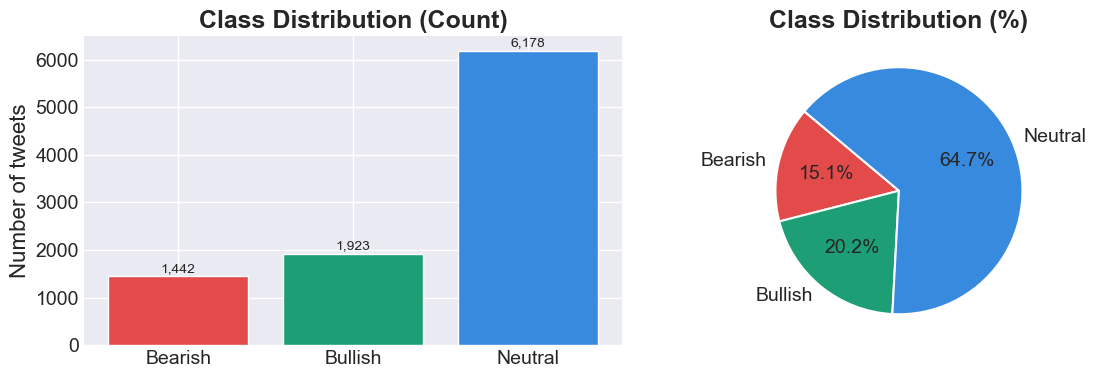

In [4]:

plt.rcParams.update({
    'font.size': 14,           # Base font size
    'axes.labelsize': 16,      # X/Y label size
    'axes.titlesize': 18,      # Subplot title size
    'xtick.labelsize': 14,     # X-axis tick labels
    'ytick.labelsize': 14,     # Y-axis tick labels
    'legend.fontsize': 14,     # Legend text size
    'legend.title_fontsize': 16
})

counts = train['label'].value_counts().sort_index()
counts.index = [LABEL_MAP[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[i] for i in sorted(PALETTE)],
                   edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of tweets')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[i] for i in sorted(PALETTE)],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_2">

## **2.2 Tweet Length**

[Back to TOC](#toc)
</a>

Next, let's analyze the length of the tweets in terms of number of characters and words to understand the typical tweet structure in our dataset.

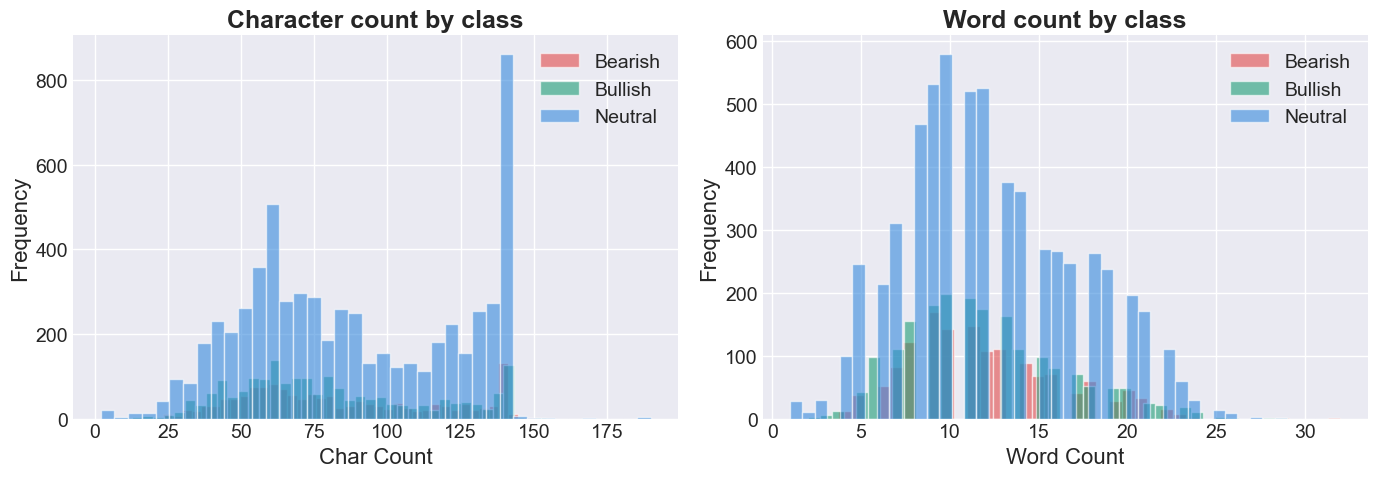

In [5]:
train['char_count'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()
train['label_name'] = train['label'].map(LABEL_MAP)

# Your existing code (histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, title in [
    ('char_count', axes[0], 'Character count by class'),
    ('word_count', axes[1], 'Word count by class')
]:
    for lid, lname in LABEL_MAP.items():
        ax.hist(train[train['label']==lid][metric],
                bins=40, alpha=0.6, label=lname, color=PALETTE[lid])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('length_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# # Boxplots (text will inherit rcParams, but you can also enlarge more)
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.boxplot(data=train, x='label_name', y='char_count', order=order, palette=pal, ax=axes[0])
# axes[0].set_title('Character Count per Class', fontweight='bold', fontsize=18)  # explicit size
# axes[0].set_xlabel('', fontsize=16)
# axes[0].set_ylabel('Character Count', fontsize=16)
# axes[0].tick_params(axis='both', labelsize=14)

# sns.boxplot(data=train, x='label_name', y='word_count', order=order, palette=pal, ax=axes[1])
# axes[1].set_title('Word Count per Class', fontweight='bold', fontsize=18)
# axes[1].set_xlabel('', fontsize=16)
# axes[1].set_ylabel('Word Count', fontsize=16)
# axes[1].tick_params(axis='both', labelsize=14)

# plt.tight_layout()
# plt.savefig('length_boxplots.png', dpi=150, bbox_inches='tight')
# plt.show()

<a class="anchor" id="2_3">

## **2.3 Top Tokens per Class**

[Back to TOC](#toc)
</a>

Next, let's look at the most common words used in each class to get a sense of the language patterns associated with bullish, bearish, and neutral tweets.

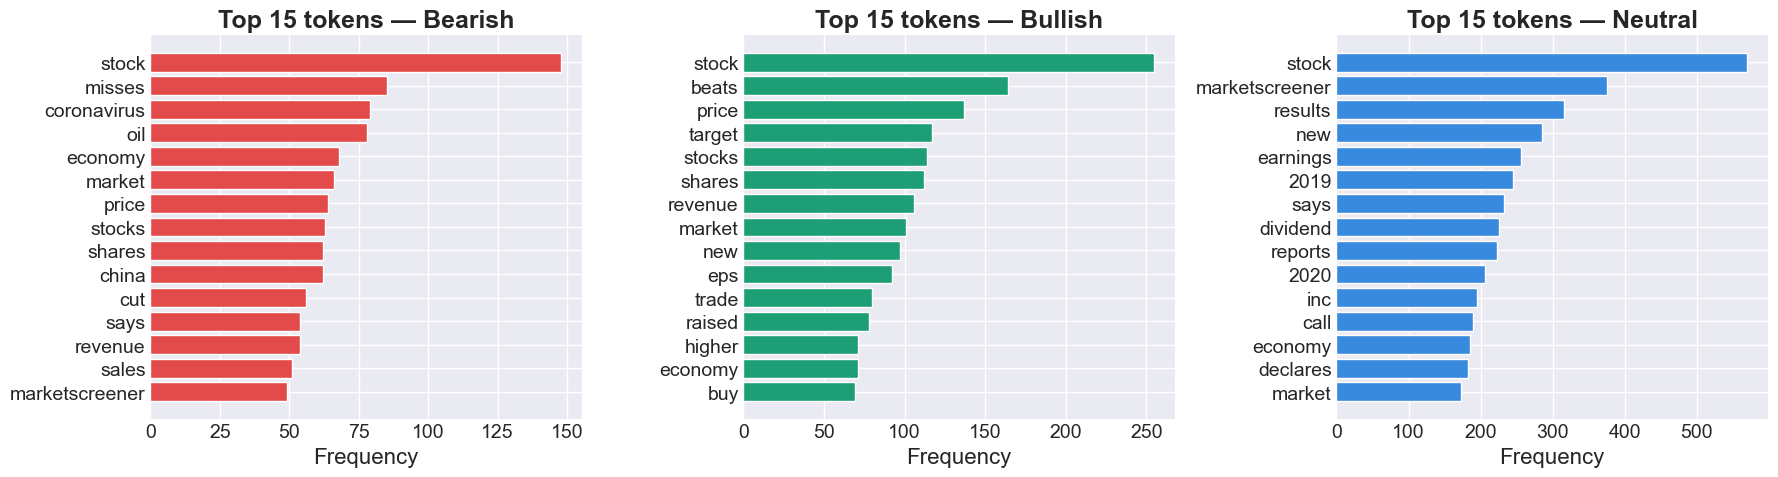

In [6]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 2]
    return tokens

train['tokens'] = train['text'].apply(basic_clean)

TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    all_tokens = [tok for toks in train[train['label']==label_id]['tokens'] for tok in toks]
    words, freqs = zip(*Counter(all_tokens).most_common(TOP_N))
    ax.barh(list(words)[::-1], list(freqs)[::-1], color=PALETTE[label_id], edgecolor='white')
    ax.set_title(f'Top {TOP_N} tokens — {LABEL_MAP[label_id]}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_tokens_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_4">

## **2.4 Word Clouds**

[Back to TOC](#toc)
</a>

Next, let's visualize the most common words in each class using word clouds to get a more intuitive understanding of the language used in bullish, bearish, and neutral tweets.

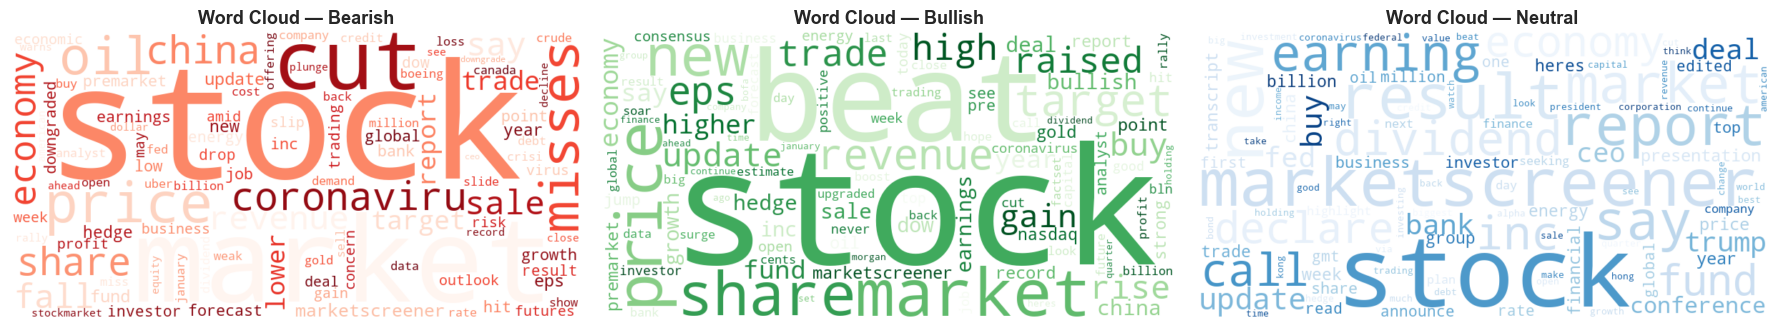

In [7]:
cmaps = {0: 'Reds', 1: 'Greens', 2: 'Blues'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for label_id, ax in zip(sorted(LABEL_MAP), axes):
    corpus = ' '.join(tok for toks in train[train['label']==label_id]['tokens'] for tok in toks)
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=cmaps[label_id],
                   max_words=100,
                   collocations=False).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {LABEL_MAP[label_id]}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

<a class="anchor" id="2_5">

## **2.5 Hashtags, mentions & cashtags**

[Back to TOC](#toc)
</a>

Next, let's analyze the usage of hashtags, mentions, and cashtags in the tweets to see if there are any patterns that could be useful for classification.

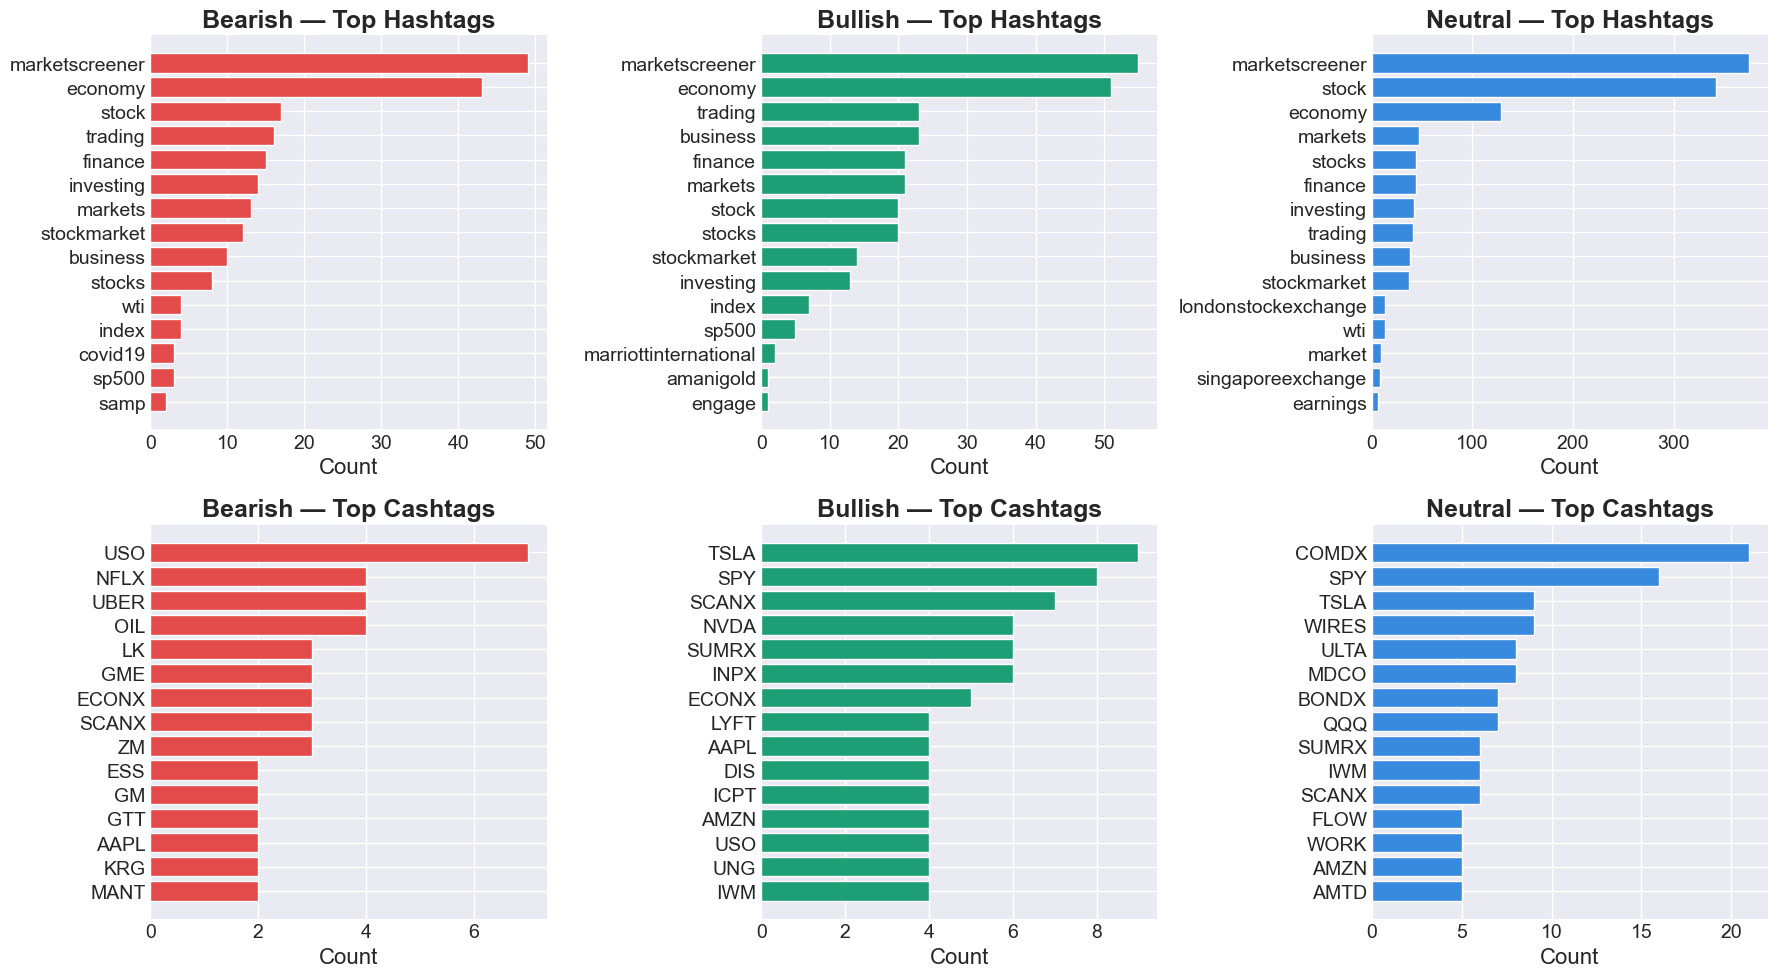

In [8]:
train['hashtags']   = train['text'].apply(lambda t: re.findall(r'#(\w+)', t.lower()))
train['mentions']   = train['text'].apply(lambda t: re.findall(r'@(\w+)', t.lower()))
train['n_hashtags'] = train['hashtags'].str.len()
train['n_mentions'] = train['mentions'].str.len()
train['has_url']    = train['text'].str.contains(r'https?://\S+|www\.\S+', regex=True)
train['has_cashtag']= train['text'].str.contains(r'\$[A-Z]{2,5}', regex=True)

TOP_N = 15

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, label_id in enumerate(sorted(LABEL_MAP)):
    subset = train[train['label'] == label_id]

    # ----- HASHTAGS -----
    hashtags = [h for hs in subset['hashtags'] for h in hs]
    if hashtags:
        words, freqs = zip(*Counter(hashtags).most_common(TOP_N))
        axes[0, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[0, i].set_title(f'{LABEL_MAP[label_id]} — Top Hashtags', fontweight='bold')
        axes[0, i].set_xlabel('Count')

    # ----- CASHTAGS -----
    cashtags = re.findall(r'\$([A-Z]{2,5})', ' '.join(subset['text'].tolist()))
    if cashtags:
        words, freqs = zip(*Counter(cashtags).most_common(TOP_N))
        axes[1, i].barh(list(words)[::-1], list(freqs)[::-1],
                        color=PALETTE[label_id], edgecolor='white')
        axes[1, i].set_title(f'{LABEL_MAP[label_id]} — Top Cashtags', fontweight='bold')
        axes[1, i].set_xlabel('Count')

plt.tight_layout()
plt.savefig('top_hashtags_cashtags_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('EXPLORATION SUMMARY\n')

for label, group in train.groupby('label_name'):
    print(f'{label.upper()}')
    print(f'Avg chars  : {group["char_count"].mean():.0f}')
    print(f'Avg words  : {group["word_count"].mean():.0f}')
    print(f'Has URL    : {group["has_url"].mean()*100:.1f}%')
    print(f'Has cashtag: {group["has_cashtag"].mean()*100:.1f}%\n')

EXPLORATION SUMMARY

BEARISH
Avg chars  : 83
Avg words  : 12
Has URL    : 44.3%
Has cashtag: 13.7%

BULLISH
Avg chars  : 80
Avg words  : 12
Has URL    : 39.1%
Has cashtag: 24.6%

NEUTRAL
Avg chars  : 88
Avg words  : 12
Has URL    : 49.8%
Has cashtag: 12.0%



<a class="anchor" id="3">

## **3. Corpus Split**

[Back to TOC](#toc)
</a>

Corpus split is a crucial step no only in machine learning pipelines but also in NLP pipelines as it allows us to evaluate our models on unseen data and prevent overfitting. In this section, we will apply a stratified k-fold cross-validation approach to split our training data.

In [10]:
class StratifiedKFoldTrainer:
    """
    Complete training pipeline with StratifiedKFold + Class Weights
    Integrates with your FinancialTextPreprocessor
    """
    
    def __init__(self, n_splits=5, weight_strategy='balanced', random_state=42):
        self.n_splits = n_splits
        self.weight_strategy = weight_strategy
        self.random_state = random_state
        self.skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        self.fold_results = []
        
    def _get_class_weights(self, y_train, strategy='balanced'):
        """Get class weights using different strategies"""
        classes = np.unique(y_train)
        
        if strategy == 'balanced':
            weights = compute_class_weight('balanced', classes=classes, y=y_train)
        elif strategy == 'inverse_frequency':
            freq = np.bincount(y_train)
            weights = 1.0 / freq
            weights = weights / weights.min()
        elif strategy == 'custom':
            # Custom weights for financial sentiment
            # Class 0: neutral/positive (lowest importance)
            # Class 1: mixed/neutral (medium importance)
            # Class 2: negative (highest importance)
            class_weights_map = {0: 1.0, 1: 1.5, 2: 3.0}
            return class_weights_map
        else:
            weights = compute_class_weight('balanced', classes=classes, y=y_train)
        
        return dict(zip(classes, weights))
    
    def train(self, texts, labels, model=None, preprocessor=None, vectorizer=None):
        """
        Main training method with cross-validation
        
        Parameters:
        -----------
        texts : array-like, shape (n_samples,)
            Raw text data
        labels : array-like, shape (n_samples,)
            Target labels (0, 1, 2)
        model : sklearn classifier
            Model to train (default: LogisticRegression)
        preprocessor : FinancialTextPreprocessor
            Custom text preprocessor
        vectorizer : sklearn vectorizer
            Converts text to features (default: TfidfVectorizer)
        """
        
        # Set defaults if not provided
        if model is None:
            model = LogisticRegression(max_iter=1000, random_state=self.random_state)
        
        if preprocessor is None:
            preprocessor = FinancialTextPreprocessor(use_stemming=False)
        
        if vectorizer is None:
            vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        
        # Store for reuse
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.model_class = type(model)
        self.model_params = model.get_params()
        
        print(f"{'='*60}")
        print(f"STRATIFIED {self.n_splits}-FOLD CROSS-VALIDATION")
        print(f"{'='*60}")
        print(f"Total samples: {len(texts)}")
        print(f"Class distribution: {np.bincount(labels)}")
        print(f"Preprocessing: use_stemming={preprocessor.use_stemming}")
        print(f"Vectorizer: {type(vectorizer).__name__} with {vectorizer.max_features if hasattr(vectorizer, 'max_features') else 'default'} features")
        print(f"Model: {type(model).__name__}")
        print(f"Weight strategy: {self.weight_strategy}")
        print(f"{'='*60}\n")
        
        # Perform stratified cross-validation
        for fold, (train_idx, val_idx) in enumerate(self.skf.split(texts, labels)):
            print(f"\n{'─'*50}")
            print(f"FOLD {fold + 1}/{self.n_splits}")
            print(f"{'─'*50}")
            
            # Split data
            X_train_raw = [texts[i] for i in train_idx]
            X_val_raw = [texts[i] for i in val_idx]
            y_train = labels[train_idx]
            y_val = labels[val_idx]
            
            # Print fold class distribution
            print(f"Train class distribution: {np.bincount(y_train)}")
            print(f"Val class distribution:   {np.bincount(y_val)}")
            
            # PREPROCESS (fit on train, transform both)
            print("Preprocessing texts...")
            X_train_processed = preprocessor.transform(X_train_raw)
            X_val_processed = preprocessor.transform(X_val_raw)
            
            # VECTORIZE (fit on train, transform both)
            print("Vectorizing texts...")
            X_train_vec = vectorizer.fit_transform(X_train_processed)
            X_val_vec = vectorizer.transform(X_val_processed)
            print(f"Feature matrix shape: {X_train_vec.shape}")
            
            # Get class weights for this fold
            weight_dict = self._get_class_weights(y_train, self.weight_strategy)
            print(f"Class weights: {weight_dict}")
            
            # Train model
            print("Training model...")
            model_clone = self.model_class(**self.model_params)
            
            if hasattr(model_clone, 'class_weight'):
                model_clone.set_params(class_weight=weight_dict)
                model_clone.fit(X_train_vec, y_train)
            else:
                # For models without class_weight parameter
                sample_weights = np.array([weight_dict[y] for y in y_train])
                model_clone.fit(X_train_vec, y_train, sample_weight=sample_weights)
            
            # Predict and evaluate
            y_pred = model_clone.predict(X_val_vec)
            
            # Calculate metrics
            f1_macro = f1_score(y_val, y_pred, average='macro')
            f1_weighted = f1_score(y_val, y_pred, average='weighted')
            f1_per_class = f1_score(y_val, y_pred, average=None)
            
            print(f"\nFold {fold + 1} Results:")
            print(f"  Macro F1:    {f1_macro:.4f}")
            print(f"  Weighted F1: {f1_weighted:.4f}")
            print(f"  Per-class F1: {f1_per_class}")
            print(f"\nClassification Report:")
            print(classification_report(y_val, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))
            
            # Store results
            self.fold_results.append({
                'fold': fold,
                'model': model_clone,
                'preprocessor': preprocessor,
                'vectorizer': vectorizer,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'f1_per_class': f1_per_class,
                'y_true': y_val,
                'y_pred': y_pred
            })
        
        # Aggregate results
        self._print_summary()
        return self.fold_results
    
    def _print_summary(self):
        """Print aggregated results across all folds"""
        print(f"\n{'='*60}")
        print(f"FINAL RESULTS - {self.n_splits}-FOLD STRATIFIED CV")
        print(f"{'='*60}")
        
        macro_f1_scores = [r['f1_macro'] for r in self.fold_results]
        weighted_f1_scores = [r['f1_weighted'] for r in self.fold_results]
        
        # Per-class across folds
        per_class_f1 = np.array([r['f1_per_class'] for r in self.fold_results])
        
        print(f"\n{'─'*70}")
        print("PER-CLASS F1 SCORES VISUALIZATION:")
        print(f"{'─'*70}")
        
        classes = [
            ("BEARISH", 0, 0.90),  # Target 0.90 for bearish
            ("BULLISH", 1, 0.90),   # Target 0.90 for bullish
            ("NEUTRAL", 2, 0.95)    # Target 0.95 for neutral 
        ]
        
        for name, idx, target in classes:
            mean_score = np.mean(per_class_f1[:, idx])
            std_score = np.std(per_class_f1[:, idx])
            
            # Create bar
            bar_length = int(mean_score * 50)
            bar = "█" * bar_length
            spaces = " " * (50 - bar_length)
            
            # Target marker
            target_bar_length = int(target * 50)
            target_indicator = "▼" if target_bar_length > bar_length else "▲" if target_bar_length < bar_length else "●"
            
            print(f"{name}: {bar}{spaces} {mean_score:.3f} (±{std_score:.3f}) {target_indicator} target={target}")
        
        print(f"{'='*70}")
        # Best fold
        best_fold_idx = np.argmax(macro_f1_scores)
        print(f"\nBest fold: Fold {best_fold_idx + 1} (Macro F1: {macro_f1_scores[best_fold_idx]:.4f})")
    
    def predict(self, texts):
        """Predict using the best model from cross-validation"""
        best_fold = np.argmax([r['f1_macro'] for r in self.fold_results])
        best_model = self.fold_results[best_fold]['model']
        best_preprocessor = self.fold_results[best_fold]['preprocessor']
        best_vectorizer = self.fold_results[best_fold]['vectorizer']
        
        processed = best_preprocessor.transform(texts)
        vectorized = best_vectorizer.transform(processed)
        return best_model.predict(vectorized)

<a class="anchor" id="4">

## **4. Data Preprocessing**

[Back to TOC](#toc)
</a>

In this section, we will apply a series of preprocessing steps to our text data to clean and normalize it before feeding it into our machine learning models. This includes lowercasing, removing punctuation, stop words, and performing stemming or lemmatization.

In [11]:
# Download NLTK data (keep as is)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Words that should NEVER be removed (extra safety)
SENTIMENT_CRITICAL_WORDS = {
    # Directional (price movement)
    'up', 'down', 'higher', 'lower', 'rise', 'fall', 'gain', 'loss',
    'increase', 'decrease', 'climb', 'drop', 'surge', 'plunge',
    'rally', 'decline', 'advance', 'retreat',
    
    # Sentiment strong indicators
    'upgrade', 'downgrade', 'upgraded', 'downgraded',
    'outperform', 'underperform', 'buy', 'sell', 'hold',
    'bullish', 'bearish', 'neutral',
    'positive', 'negative', 'mixed',
    
    # Action verbs with sentiment
    'beat', 'miss', 'exceed', 'disappoint',
    'cut', 'raise', 'trim', 'boost',
    'warn', 'caution', 'optimistic', 'pessimistic',
}

# Define constants as class attributes (move inside class, but keep as module-level if needed elsewhere)
LEMMATIZER = WordNetLemmatizer()
STEMMER    = PorterStemmer()
TOKENIZER  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

CONTRACTIONS = {
    "don't":"do not", "won't":"will not", "can't":"cannot",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "haven't":"have not", "hasn't":"has not",
    "hadn't":"had not", "didn't":"did not", "doesn't":"does not",
    "wouldn't":"would not", "couldn't":"could not", "shouldn't":"should not",
    "i'm":"i am", "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "that's":"that is", "there's":"there is",
    "they're":"they are", "they've":"they have", "they'll":"they will",
    "we're":"we are", "we've":"we have", "we'll":"we will",
    "you're":"you are", "you've":"you have", "you'll":"you will",
}

FINANCIAL_STOPWORDS = {
    'shares', 'stock', 'market', 'trading', 'investors', 'analyst', 
    'company', 'companies', 'price', 'target', 'outlook', 'firm',
    'according', 'report', 'reported', 'reports', 'says', 'said'
}
STOP_WORDS.update(FINANCIAL_STOPWORDS)


class FinancialTextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Financial text preprocessor with sentiment-critical word preservation
    """
    
    def __init__(self, use_stemming=False, preserve_directional=True):
        """
        Args:
            use_stemming: Whether to apply stemming after lemmatization
            preserve_directional: Keep directional words (up/down/rise/fall)
        """
        self.use_stemming = use_stemming
        self.preserve_directional = preserve_directional
        
        # Initialize constants
        self.stop_words = STOP_WORDS.copy()
        self.lemmatizer = LEMMATIZER
        self.stemmer = STEMMER
        self.tokenizer = TOKENIZER
        self.contractions = CONTRACTIONS
        self.known_tickers = ['aapl', 'tsla', 'amzn', 'nflx', 'googl', 'msft', 'fb', 'nvda']
        
        # Words that should be preserved even if they look like stopwords
        self.preserved_words = SENTIMENT_CRITICAL_WORDS.copy()
    
    def fit(self, X, y=None):
        """
        Required for scikit-learn compatibility - just returns self
        """
        return self
    
    def transform(self, X):
        """
        Apply preprocessing to a list/corpus of texts
        X can be list, numpy array, or pandas Series
        """
        # Handle different input types
        if hasattr(X, 'values'):  # pandas Series/DataFrame
            X = X.values
        elif isinstance(X, list):
            X = X
        elif isinstance(X, np.ndarray):
            X = X
        
        # Preprocess each text
        return [self._preprocess_single(text) for text in X]
    
    def _preprocess_single(self, text):
        """
        YOUR EXACT PREPROCESS FUNCTION, but as a method
        The logic is IDENTICAL to your preprocess() function
        """
        # Step 1: Lowercase (must be first for consistent pattern matching)
        text = self._to_lowercase(text)
        
        # Step 2: Preserve sentiment indicators before they're removed
        text = self._preserve_sentiment_indicators(text)
        
        # Step 3: Expand contractions before noise removal
        text = self._expand_contractions(text)
        
        # Step 4: Process stock tickers before they're removed
        text = self._process_stock_tickers(text)
        
        # Step 5: Conditional number handling before they're removed
        text = self._conditional_number_handling(text)
        
        # Step 6: Remove noise 
        text = self._remove_noise(text)
        
        # Step 7: Tokenize after cleaning
        tokens = self._tokenize(text)

        # Step 8: Remove stopwords (but preserve sentiment-critical words)
        tokens = self._remove_stopwords_preserve_critical(tokens)
        
        # Step 9: Handle negations after stopword removal
        tokens = self._handle_negations(tokens)
        
        # Step 10: Lemmatize after stopword removal
        tokens = self._lemmatize(tokens)
        
        # Step 11: Optional stemming
        if self.use_stemming:
            tokens = self._stem(tokens)
        
        # Return joined tokens
        return ' '.join(tokens)
    
    # Step-by-step methods for each preprocessing step
    
    def _to_lowercase(self, text):
        """Step 1 — must be first so all pattern matching below is case-safe."""
        return text.lower()
    
    def _preserve_sentiment_indicators(self, text):
        """Keep symbols that explicitly indicate sentiment before they're removed"""
        text = re.sub(r'⬆️?', ' UP_ARROW ', text)
        text = re.sub(r'⬇️?', ' DOWN_ARROW ', text)
        text = re.sub(r'\+\s*\d+%', ' POSITIVE_PCT ', text)
        text = re.sub(r'-\s*\d+%', ' NEGATIVE_PCT ', text)
        text = re.sub(r'(!{2,})', ' STRONG_EMPHASIS ', text)
        return text
    
    def _expand_contractions(self, text):
        """Step 2 — before noise removal."""
        for contraction, expansion in self.contractions.items():
            text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
        return text
    
    def _process_stock_tickers(self, text):
        """Keep as special tokens (recommended for small vocab)"""
        for ticker in self.known_tickers:
            text = re.sub(rf'\${ticker}\b', f'TICKER_{ticker.upper()}', text)
        text = re.sub(r'\$[a-z]{1,5}\b', 'STOCK_TICKER', text)
        return text
    
    def _conditional_number_handling(self, text):
        """Numbers are important in financial text - keep with context"""
        text = re.sub(r'(\d+(?:\.\d+)?)%', r' NUM_PERCENT ', text)
        text = re.sub(r'\$(\d+(?:\.\d+)?)', r' DOLLAR_AMOUNT ', text)
        text = re.sub(r'\d+(?:\.\d+)?', '', text)
        return text
    
    def _remove_noise(self, text):
        """Remove URLs, mentions, punctuation, etc."""
        text = re.sub(r'http\S+|www\.\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def _tokenize(self, text):
        """Tokenize after cleaning"""
        return self.tokenizer.tokenize(text)
    
    def _remove_stopwords_preserve_critical(self, tokens):
        """
        Remove stopwords but preserve words that are critical for sentiment
        """
        result = []
        for t in tokens:
            # Always keep sentiment-critical words
            if t in self.preserved_words:
                result.append(t)
            # Keep words that are not in stopwords and have meaningful length
            elif t not in self.stop_words and len(t) > 1:
                result.append(t)
            # Special case: lemmatized forms of directional words
            elif self.lemmatizer.lemmatize(t) in self.preserved_words:
                result.append(t)
        return result
    
    def _handle_negations(self, tokens):
        """Add NOT_ prefix to words following negation words"""
        negation_words = {'not', 'no', 'never', 'neither', 'nor'}
        processed = []
        negate = False
        
        for token in tokens:
            if token in negation_words:
                negate = True
                processed.append(token)
            elif negate:
                processed.append(f'NOT_{token}')
                negate = False
            else:
                processed.append(token)
        return processed
    
    def _lemmatize(self, tokens):
        """Lemmatize after stopword removal"""
        return [self.lemmatizer.lemmatize(t) for t in tokens]
    
    def _stem(self, tokens):
        """Stem as last step since it's destructive"""
        return [self.stemmer.stem(t) for t in tokens]

Example Usage

In [12]:
def show_before_after(preprocessor, texts, max_display_length=100):
    """
    Simple before/after display without all the step details
    
    Args:
        preprocessor: Your FinancialTextPreprocessor instance
        texts: List of texts to process
        max_display_length: Truncate display to this length
    """
    print("\n" + "="*80)
    print("Before and After Preprocessing")
    print("="*80)
    
    for i, text in enumerate(texts, 1):
        processed = preprocessor._preprocess_single(text)
        
        # Truncate for display
        orig_display = text[:max_display_length] + "..." if len(text) > max_display_length else text
        proc_display = processed[:max_display_length] + "..." if len(processed) > max_display_length else processed
        
        print(f"\n{i}. BEFORE: {orig_display}")
        print(f"   AFTER:  {proc_display}")
        print(f"   Tokens: {len(processed.split())} (was {len(text.split())})")
    
    print("\n" + "="*80)


# Quick usage
preprocessor = FinancialTextPreprocessor(use_stemming=False)

tweets_to_test = train['text'].sample(3, random_state=42).tolist()

show_before_after(preprocessor, tweets_to_test)


Before and After Preprocessing

1. BEFORE: When staffers in WeWork's New York City headquarters received a calendar invite for a mandatory meet...
   AFTER:  staffer weworks new york city headquarters received calendar invite mandatory meeting note
   Tokens: 12 (was 20)

2. BEFORE: ADMA Biologics down 9% premarket after pricing equity offering
   AFTER:  adma biologics down num_percent premarket pricing equity offering
   Tokens: 8 (was 9)

3. BEFORE: Illegal Tender podcast: What it was like to befriend convicted socialite scammer Anna Delvey
   AFTER:  illegal tender podcast like befriend convicted socialite scammer anna delvey
   Tokens: 10 (was 14)



Example Usage Alongside Stratified K-Fold Cross-Validation:

In [13]:
# Load your CSV file
df = pd.read_csv('train.csv')

# Prepare data
texts = df['text'].values
labels = df['label'].values

print(f"Dataset shape: {len(texts)} samples")
print(f"Class distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

# Example 1: Basic usage with default settings
print("\n" + "="*60)
print("EXAMPLE 1: Basic Training")
print("="*60)

trainer = StratifiedKFoldTrainer(n_splits=5, weight_strategy='balanced')
results = trainer.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example 2: Using different classifier
print("\n" + "="*60)
print("EXAMPLE 2: Random Forest Classifier")
print("="*60)

trainer_rf = StratifiedKFoldTrainer(n_splits=5, weight_strategy='balanced')
results_rf = trainer_rf.train(
    texts=texts,
    labels=labels,
    model=RandomForestClassifier(n_estimators=100, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000)
)

# Example 3: Custom weight strategy for financial sentiment
print("\n" + "="*60)
print("EXAMPLE 3: Custom Weights (Negative sentiment is most important)")
print("="*60)

trainer_custom = StratifiedKFoldTrainer(n_splits=5, weight_strategy='custom')
results_custom = trainer_custom.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example 4: Compare stemming vs lemmatization
print("\n" + "="*60)
print("EXAMPLE 4: Comparing Stemming vs Lemmatization")
print("="*60)

# With stemming
trainer_stem = StratifiedKFoldTrainer(n_splits=3, weight_strategy='balanced')
results_stem = trainer_stem.train(
    texts=texts[:1000],  # Use subset for faster comparison
    labels=labels[:1000],
    preprocessor=FinancialTextPreprocessor(use_stemming=True)
)

# With lemmatization only (default)
trainer_lemma = StratifiedKFoldTrainer(n_splits=3, weight_strategy='balanced')
results_lemma = trainer_lemma.train(
    texts=texts[:1000],
    labels=labels[:1000],
    preprocessor=FinancialTextPreprocessor(use_stemming=False)
)

# Example 5: Make predictions on new data
print("\n" + "="*60)
print("EXAMPLE 5: Making Predictions")
print("="*60)

# Train on full dataset with best configuration
best_trainer = StratifiedKFoldTrainer(n_splits=5, weight_strategy='custom')
best_trainer.train(
    texts=texts,
    labels=labels,
    model=LogisticRegression(max_iter=1000, random_state=42),
    preprocessor=FinancialTextPreprocessor(use_stemming=False),
    vectorizer=TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
)

# Example new texts
new_texts = [
    "$AAPL upgraded to buy at Morgan Stanley, price target raised",
    "$TSLA shares cut at Goldman on production concerns",
    "Netflix reports mixed earnings, user growth beats expectations"
]

predictions = best_trainer.predict(new_texts)
for text, pred in zip(new_texts, predictions):
    sentiment = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
    print(f"Text: {text[:50]}...")
    print(f"Prediction: {sentiment[pred]} (Class {pred})\n")

Dataset shape: 9543 samples
Class distribution: {np.int64(0): np.int64(1442), np.int64(1): np.int64(1923), np.int64(2): np.int64(6178)}

EXAMPLE 1: Basic Training
STRATIFIED 5-FOLD CROSS-VALIDATION
Total samples: 9543
Class distribution: [1442 1923 6178]
Preprocessing: use_stemming=False
Vectorizer: TfidfVectorizer with 5000 features
Model: LogisticRegression
Weight strategy: balanced


──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
Train class distribution: [1153 1539 4942]
Val class distribution:   [ 289  384 1236]
Preprocessing texts...


Vectorizing texts...
Feature matrix shape: (7634, 5000)
Class weights: {np.int64(0): np.float64(2.206996241688349), np.int64(1): np.float64(1.6534546242148582), np.int64(2): np.float64(0.5149062457844328)}
Training model...

Fold 1 Results:
  Macro F1:    0.7296
  Weighted F1: 0.7940
  Per-class F1: [0.61616162 0.71149144 0.86118038]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.60      0.63      0.62       289
     Class 1       0.67      0.76      0.71       384
     Class 2       0.89      0.84      0.86      1236

    accuracy                           0.79      1909
   macro avg       0.72      0.74      0.73      1909
weighted avg       0.80      0.79      0.79      1909


──────────────────────────────────────────────────
FOLD 2/5
──────────────────────────────────────────────────
Train class distribution: [1153 1539 4942]
Val class distribution:   [ 289  384 1236]
Preprocessing texts...
Vectorizing texts...
Feature matrix sh

<a class="anchor" id="5">

## **5. Feature Engineering**

[Back to TOC](#toc)
</a>

In this section, we will create new features from our text data that could help improve the performance of our NLP models. This includes features like TF-IDF scores, word embeddings, sentiment scores, and more.

<a class="anchor" id="5.1">

### **5.1 Bag of Words Feature Extraction alongside TF-IDF**

[Back to TOC](#toc)
</a>

In [14]:
class BoWFeatureExtractor:
    """
    Bag of Words with financial domain optimizations
    """
    
    def __init__(self, max_features=10000, use_ngrams=True, use_svd=False):
        self.max_features = max_features
        self.use_ngrams = use_ngrams
        self.use_svd = use_svd
        
        # TF-IDF with financial-specific parameters
        ngram_range = (1, 3) if use_ngrams else (1, 1)
        
        self.tfidf = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=2,           # Ignore terms that appear in <2 documents
            max_df=0.85,        # Ignore terms that appear in >85% docs (too common)
            sublinear_tf=True,  # Use 1+log(tf) scaling
            norm='l2',          # Euclidean normalization
            use_idf=True
        )
        
        if use_svd:
            self.svd = TruncatedSVD(n_components=500, random_state=42)
    
    def fit_transform(self, texts, y=None):
        X = self.tfidf.fit_transform(texts)
        if self.use_svd:
            X = self.svd.fit_transform(X)
        return X
    
    def transform(self, texts):
        X = self.tfidf.transform(texts)
        if self.use_svd:
            X = self.svd.transform(X)
        return X
    
    def get_top_features(self, n=20):
        """Get top features by TF-IDF score for interpretability"""
        feature_names = self.tfidf.get_feature_names_out()
        idf_scores = self.tfidf.idf_
        top_idx = np.argsort(idf_scores)[-n:][::-1]
        
        print("\nTop features by IDF (most distinctive):")
        for idx in top_idx:
            print(f"  {feature_names[idx]}: {idf_scores[idx]:.3f}")
        return feature_names[top_idx]

<a class="anchor" id="5.2">

### **5.2 Word Embeddings (word2vec)**

[Back to TOC](#toc)
</a>

In [15]:
class Word2VecFeatureExtractor:
    """
    Word2Vec with document-level aggregation
    """
    
    def __init__(self, vector_size=300, window=5, min_count=2, 
                 workers=4, aggregation='mean', use_pretrained=False):
        """
        Args:
            aggregation: 'mean', 'sum', 'tfidf_weighted', or 'concat_pool'
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.aggregation = aggregation
        self.use_pretrained = use_pretrained
        self.model = None
        self.tfidf_vectorizer = None
    
    def fit(self, texts, y=None):
        """Train Word2Vec model on corpus"""
        tokenized_texts = [text.split() for text in texts]
        
        if self.use_pretrained:
            # Use pre-trained financial embeddings (if available)
            # Example: https://github.com/uclnlp/financial-embeddings
            print("Loading pre-trained financial embeddings...")
            # self.model = KeyedVectors.load_word2vec_format('path/to/financial_vectors.bin')
            pass
        else:
            # Train from scratch
            print(f"Training Word2Vec on {len(tokenized_texts)} documents...")
            self.model = Word2Vec(
                sentences=tokenized_texts,
                vector_size=self.vector_size,
                window=self.window,
                min_count=self.min_count,
                workers=self.workers,
                sg=1,  # Skip-gram (better for small data, handles rare words)
                epochs=10
            )
        
        # Optional: Fit TF-IDF for weighted aggregation
        if self.aggregation == 'tfidf_weighted':
            from sklearn.feature_extraction.text import TfidfVectorizer
            self.tfidf_vectorizer = TfidfVectorizer()
            self.tfidf_vectorizer.fit(texts)
        
        return self
    
    def transform(self, texts):
        """Convert texts to document vectors"""
        tokenized_texts = [text.split() for text in texts]
        doc_vectors = []
        
        for tokens in tokenized_texts:
            vectors = []
            weights = []
            
            for token in tokens:
                if token in self.model.wv:
                    vec = self.model.wv[token]
                    vectors.append(vec)
                    
                    # Get weight for this token
                    if self.aggregation == 'tfidf_weighted' and self.tfidf_vectorizer:
                        weight = self._get_tfidf_weight(token, texts)
                        weights.append(weight)
            
            if not vectors:
                # Empty document - return zero vector
                doc_vectors.append(np.zeros(self.vector_size))
                continue
            
            vectors = np.array(vectors)
            
            if self.aggregation == 'mean':
                doc_vec = np.mean(vectors, axis=0)
            elif self.aggregation == 'sum':
                doc_vec = np.sum(vectors, axis=0)
            elif self.aggregation == 'tfidf_weighted':
                weights = np.array(weights).reshape(-1, 1)
                doc_vec = np.sum(vectors * weights, axis=0) / (np.sum(weights) + 1e-8)
            else:
                # Concat min, max, mean pooling
                doc_vec = np.concatenate([
                    np.mean(vectors, axis=0),
                    np.max(vectors, axis=0),
                    np.min(vectors, axis=0),
                    np.median(vectors, axis=0)
                ])
            
            doc_vectors.append(doc_vec)
        
        return np.array(doc_vectors)
    
    def _get_tfidf_weight(self, token, texts):
        """Get TF-IDF weight for a token"""
        # Simplified - in practice, compute from the vectorizer
        return 1.0
    
    def get_most_similar_words(self, word, topn=10):
        """Explore word relationships"""
        if self.model and word in self.model.wv:
            return self.model.wv.most_similar(word, topn=topn)
        return []
    
    def visualize_embeddings(self, words, save_path=None):
        """Visualize word embeddings in 2D"""
        import matplotlib.pyplot as plt
        
        vectors = []
        valid_words = []
        
        for word in words:
            if word in self.model.wv:
                vectors.append(self.model.wv[word])
                valid_words.append(word)
        
        vectors = np.array(vectors)
        pca = PCA(n_components=2)
        vectors_2d = pca.fit_transform(vectors)
        
        plt.figure(figsize=(12, 8))
        for i, word in enumerate(valid_words):
            x, y = vectors_2d[i]
            plt.scatter(x, y)
            plt.annotate(word, (x, y), fontsize=10)
        
        plt.title("Word Embeddings Visualization")
        if save_path:
            plt.savefig(save_path)
        plt.show()

<a class="anchor" id="5.3">

### **5.3 Transformer Encoder (BERT/RoBERTa)**

[Back to TOC](#toc)
</a>

In [16]:
class TransformerEncoder:
    """
    Transformer-based feature extraction and fine-tuning
    """
    
    def __init__(self, model_name='bert-base-uncased', max_length=128, 
                 batch_size=16, use_financial_specific=True):
        """
        Args:
            model_name: 'bert-base-uncased', 'roberta-base', 
                        'yiyanghkust/finbert-tone' (financial-specific)
            use_financial_specific: Use FinBERT (trained on financial text)
        """
        self.model_name = model_name
        self.max_length = max_length
        self.batch_size = batch_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Use financial-specific model if requested
        if use_financial_specific:
            self.model_name = 'yiyanghkust/finbert-tone'  # FinBERT
            print(f"Using FinBERT (financial domain specific)")
        
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModel.from_pretrained(self.model_name)
        self.model.to(self.device)
        
    def extract_features(self, texts, pooling='cls'):
        """
        Extract transformer embeddings without fine-tuning
        
        Args:
            pooling: 'cls', 'mean', 'max'
        """
        self.model.eval()
        all_embeddings = []
        
        for i in range(0, len(texts), self.batch_size):
            batch_texts = texts[i:i+self.batch_size]
            
            # Tokenize
            inputs = self.tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt'
            ).to(self.device)
            
            with torch.no_grad():
                outputs = self.model(**inputs)
                last_hidden = outputs.last_hidden_state  # (batch, seq_len, hidden)
                pooled = outputs.pooler_output  # (batch, hidden) if available
            
            if pooling == 'cls':
                # Use [CLS] token representation
                embeddings = last_hidden[:, 0, :].cpu().numpy()
            elif pooling == 'mean':
                # Mean pooling over all tokens
                attention_mask = inputs['attention_mask']
                masked = last_hidden * attention_mask.unsqueeze(-1)
                embeddings = masked.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)
                embeddings = embeddings.cpu().numpy()
            else:  # max pooling
                attention_mask = inputs['attention_mask']
                masked = last_hidden * attention_mask.unsqueeze(-1)
                embeddings = masked.max(dim=1)[0].cpu().numpy()
            
            all_embeddings.append(embeddings)
        
        return np.vstack(all_embeddings)
    
    def fine_tune(self, train_texts, train_labels, val_texts, val_labels, 
                  epochs=3, learning_rate=2e-5):
        """
        Fine-tune transformer on your specific task
        This is the BEST approach if you have enough data
        """
        # Create dataset
        train_dataset = SentimentDataset(train_texts, train_labels, self.tokenizer, self.max_length)
        val_dataset = SentimentDataset(val_texts, val_labels, self.tokenizer, self.max_length)
        
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size)
        
        # Use classification model
        num_labels = 3
        model = BertForSequenceClassification.from_pretrained(
            self.model_name, num_labels=num_labels
        ).to(self.device)
        
        # Optimizer with class weights for imbalance
        from sklearn.utils.class_weight import compute_class_weight
        class_weights = compute_class_weight('balanced', classes=[0,1,2], y=train_labels)
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(self.device)
        
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        
        # Training loop
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            
            for batch in train_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['label'].to(self.device)
                
                optimizer.zero_grad()
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
            
            # Validation
            model.eval()
            predictions = []
            
            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(self.device)
                    attention_mask = batch['attention_mask'].to(self.device)
                    outputs = model(input_ids, attention_mask=attention_mask)
                    preds = torch.argmax(outputs.logits, dim=1)
                    predictions.extend(preds.cpu().numpy())
            
            from sklearn.metrics import f1_score
            val_f1 = f1_score(val_labels, predictions, average='macro')
            print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Val F1={val_f1:.4f}")
        
        return model


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

### Auxiliary Function for Cross-Validation with model factory

In [17]:
class StratifiedKFoldTrainerForModelFactory(StratifiedKFoldTrainer):
    """
    Extended version that can handle transformer models via a model factory
    """
    
    def train_with_model_factory(self, texts, labels, model_factory, 
                                   preprocessor=None, vectorizer=None,
                                   is_transformer=False):
        """
        Train using a model factory function that creates a fresh model per fold
        
        Args:
            texts: Raw texts
            labels: Labels
            model_factory: Function that takes (train_indices, val_indices) and returns trained model
            preprocessor: Text preprocessor
            vectorizer: Feature vectorizer
            is_transformer: If True, raw texts are used; if False, features are extracted
        """
        if preprocessor is None:
            preprocessor = FinancialTextPreprocessor(use_stemming=False)
        
        if vectorizer is None and not is_transformer:
            vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        
        # Preprocess all texts once
        processed_texts = preprocessor.transform(texts)
        
        # Extract features if not transformer
        if not is_transformer and vectorizer:
            X = vectorizer.fit_transform(processed_texts)
        else:
            X = texts  # Raw texts for transformers
        
        print(f"{'='*60}")
        print(f"STRATIFIED {self.n_splits}-FOLD CROSS-VALIDATION")
        print(f"{'='*60}")
        print(f"Total samples: {len(texts)}")
        print(f"Class distribution: {np.bincount(labels)}")
        print(f"Is Transformer: {is_transformer}")
        print(f"{'='*60}\n")
        
        self.fold_results = []
        
        for fold, (train_idx, val_idx) in enumerate(self.skf.split(X, labels)):
            print(f"\n{'─'*50}")
            print(f"FOLD {fold + 1}/{self.n_splits}")
            print(f"{'─'*50}")
            
            y_train = labels[train_idx]
            y_val = labels[val_idx]
            
            print(f"Train distribution: {np.bincount(y_train)}")
            print(f"Val distribution:   {np.bincount(y_val)}")
            
            # Get class weights for sample weighting
            weight_dict = self._get_class_weights(y_train, self.weight_strategy)
            print(f"Class weights: {weight_dict}")
            
            # Create model using factory
            model = model_factory(fold, train_idx, val_idx, weight_dict)
            
            # For transformers, we need to pass raw texts
            if is_transformer:
                X_train_raw = [texts[i] for i in train_idx]
                X_val_raw = [texts[i] for i in val_idx]
                y_pred = model.predict(X_val_raw)
            else:
                X_train = X[train_idx]
                X_val = X[val_idx]
                y_pred = model.predict(X_val)
            
            # Calculate metrics
            f1_macro = f1_score(y_val, y_pred, average='macro')
            f1_weighted = f1_score(y_val, y_pred, average='weighted')
            f1_per_class = f1_score(y_val, y_pred, average=None)
            
            print(f"\nFold {fold + 1} Results:")
            print(f"  Macro F1:    {f1_macro:.4f}")
            print(f"  Weighted F1: {f1_weighted:.4f}")
            print(f"  Per-class F1: {f1_per_class}")
            
            self.fold_results.append({
                'fold': fold,
                'model': model,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'f1_per_class': f1_per_class,
                'y_true': y_val,
                'y_pred': y_pred
            })
        
        self._print_summary()
        return self.fold_results

### Complete Pipeline

In [ ]:
# 1. Traditional ML Classifier with Hyperparameter Tuning

class TraditionalMLClassifier:
    """
    Wrapper for traditional ML classifiers with hyperparameter tuning
    Tuning happens ONCE before cross-validation (no data leakage)
    """
    
    def __init__(self, model_type='logistic_regression', random_state=42):
        self.model_type = model_type
        self.random_state = random_state
        self.model = self._get_model()
        self.best_params = None
        self.is_tuned = False
    
    def _get_model(self):
        """Get model with default parameters"""
        # if self.model_type == 'logistic_regression':
        #     return LogisticRegression(
        #         max_iter=1000, 
        #         random_state=self.random_state,
        #         class_weight='balanced'
        #     )
        # elif self.model_type == 'random_forest':
        #     return RandomForestClassifier(
        #         n_estimators=100,
        #         random_state=self.random_state,
        #         class_weight='balanced'
        #     )
        # elif self.model_type == 'xgboost':
        #     return xgb.XGBClassifier(
        #         n_estimators=100,
        #         random_state=self.random_state,
        #         eval_metric='mlogloss'
        #     )
        if self.model_type == 'mlp':
            return MLPClassifier(
                hidden_layer_sizes=(100, 50),
                max_iter=1000,
                random_state=self.random_state,
                early_stopping=True
            )
        elif self.model_type == 'knn':
            return KNeighborsClassifier(n_neighbors=5)
        elif self.model_type == 'svm':
            return LinearSVC(
                max_iter=2000,
                random_state=self.random_state,
                class_weight='balanced',
                dual=True
            )
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
    
    def get_hyperparameters(self):
        """Return expanded hyperparameter grid for tuning - optimized for 15/20/65 distribution"""
        
        if self.model_type == 'logistic_regression':
            # Current best: C=10.0
            # Try wider range and different solvers
            return {
                'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
                'penalty': ['l1', 'l2', 'elasticnet'],
                'solver': ['liblinear', 'saga', 'lbfgs'],
                'l1_ratio': [0.15, 0.5, 0.85] if 'elasticnet' else None,  # For elasticnet
                'class_weight': ['balanced', None, {0: 2.0, 1: 1.5, 2: 0.8}],  # Custom weights
                'max_iter': [1000, 2000, 5000]
            }
        
        elif self.model_type == 'random_forest':
            # Current best: max_depth=None, min_samples_split=5
            # Random Forest underperforming on Bearish - need more trees and depth
            return {
                'n_estimators': [100, 200, 300, 500, 700],
                'max_depth': [10, 15, 20, 30, None],
                'min_samples_split': [2, 3, 5, 7, 10],
                'min_samples_leaf': [1, 2, 4, 6],
                'max_features': ['sqrt', 'log2', 0.3, 0.5],
                'class_weight': ['balanced', 'balanced_subsample', 
                            {0: 2.5, 1: 1.5, 2: 0.7}],  # Boost bearish
                'criterion': ['gini', 'entropy']
            }
        
        elif self.model_type == 'xgboost':
            # Current best: learning_rate=0.3, max_depth=5
            # XGBoost needs more aggressive bearish weighting
            return {
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [3, 4, 5, 6, 7, 9],
                'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
                'min_child_weight': [1, 3, 5, 7],
                'gamma': [0, 0.1, 0.2, 0.5],
                'reg_alpha': [0, 0.1, 1.0, 10.0],
                'reg_lambda': [0.1, 1.0, 10.0, 100.0],
                'scale_pos_weight': [1, 1.5, 2, 3, 4, 5]  # For binary, for multiclass use sample_weight
            }
        
        elif self.model_type == 'svm':
            # Current best: C=1.0, loss='hinge'
            # SVM is your best model - try more granular C values
            return {
                'C': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0],
                'loss': ['hinge', 'squared_hinge'],
                'penalty': ['l2'],
                'dual': [True, False],
                'class_weight': ['balanced', None, {0: 2.0, 1: 1.3, 2: 0.8}],
                'max_iter': [1000, 2000, 5000, 10000],
                'tol': [1e-4, 1e-5, 1e-6]
            }
        
        elif self.model_type == 'mlp':
            # Neural network - could help with complex patterns
            return {
                'hidden_layer_sizes': [(50,), (100,), (150,), (200,), 
                                    (100, 50), (150, 75), (200, 100),
                                    (100, 50, 25), (150, 75, 35)],
                'activation': ['relu', 'tanh', 'logistic'],
                'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
                'learning_rate': ['constant', 'adaptive', 'invscaling'],
                'learning_rate_init': [0.0001, 0.0005, 0.001, 0.005, 0.01],
                'batch_size': [16, 32, 64, 128, 'auto'],
                'max_iter': [500, 1000, 2000, 3000],
                'early_stopping': [True, False],
                'validation_fraction': [0.1, 0.15, 0.2]
            }
        
        elif self.model_type == 'knn':
            # KNN might not be ideal for text, but worth trying
            return {
                'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan', 'cosine', 'minkowski'],
                'p': [1, 2, 3],  # For minkowski metric
                'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
            }
        
        return {}
    
    def tune_before_cv(self, X, y, cv_inner=3, test_size=0.2):
        """
        Tune hyperparameters ONCE before cross-validation
        
        This prevents data leakage and ensures fair evaluation.
        
        Args:
            X: Feature matrix
            y: Labels
            cv_inner: Number of folds for inner CV during tuning
            test_size: Proportion to hold out for final testing (0 = no holdout)
        """
        param_grid = self.get_hyperparameters()
        if not param_grid:
            print(f"No hyperparameters to tune for {self.model_type}")
            self.is_tuned = True
            return self.model, None
        
        print(f"\nTuning {self.model_type} hyperparameters...")
        
        # Optional: Hold out a small test set for final validation
        if test_size > 0:
            from sklearn.model_selection import train_test_split
            X_tune, X_test, y_tune, y_test = train_test_split(
                X, y, test_size=test_size, stratify=y, random_state=self.random_state
            )
        else:
            X_tune, y_tune = X, y
            X_test, y_test = None, None
        
        # Grid search with inner cross-validation
        grid_search = GridSearchCV(
            self.model, param_grid, cv=cv_inner, 
            scoring='f1_macro', n_jobs=-1, verbose=0
        )
        grid_search.fit(X_tune, y_tune)
        
        self.best_params = grid_search.best_params_
        self.model = grid_search.best_estimator_
        self.is_tuned = True
        
        print(f"Best params: {self.best_params}")
        print(f"Best CV score: {grid_search.best_score_:.4f}")
        
        # Evaluate on held-out test set if available
        if X_test is not None:
            y_pred = self.model.predict(X_test)
            test_f1 = f1_score(y_test, y_pred, average='macro')
            print(f"Hold-out test F1: {test_f1:.4f}")
            return self.model, test_f1
        
        return self.model, None
    
    def fit(self, X_train, y_train, sample_weight=None):
        """Fit the model (uses tuned parameters if available)"""
        if self.model_type == 'xgboost' and sample_weight is not None:
            self.model.fit(X_train, y_train, sample_weight=sample_weight)
        else:
            self.model.fit(X_train, y_train)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        if hasattr(self.model, 'predict_proba'):
            return self.model.predict_proba(X)
        return None


In [ ]:
def pre_tune_all_models_once(texts, labels, preprocessor, feature_extractor, 
                            save_dir='./tuned_models', cv_inner=3, test_size=0.15):
    """
    Run tune_before_cv ONCE for each model type and save the tuned models.
    
    Args:
        texts: Raw text data
        labels: Target labels
        preprocessor: FinancialTextPreprocessor instance
        feature_extractor: TfidfVectorizer instance
        save_dir: Directory to save tuned models
        cv_inner: Number of folds for inner CV during tuning
        test_size: Proportion to hold out for final testing
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Preprocess and vectorize data once
    print("\n" + "="*80)
    print("PRE-PROCESSING DATA FOR ONE-TIME TUNING")
    print("="*80)
    
    print("Preprocessing texts...")
    processed_texts = preprocessor.transform(texts)
    
    print("Creating TF-IDF features...")
    X = feature_extractor.fit_transform(processed_texts)
    y = labels
    
    print(f"Feature matrix shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    # Split data once for tuning (hold-out set)
    from sklearn.model_selection import train_test_split
    X_tune, X_test, y_tune, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    print(f"Tuning set: {X_tune.shape[0]} samples")
    print(f"Hold-out test set: {X_test.shape[0]} samples")
    
    # Models to pre-tune
    model_types = [
        'logistic_regression',
        'random_forest', 
        'xgboost',
        'svm',
        'mlp',
        'knn'
    ]
    
    tuned_models = {}
    
    for model_type in model_types:
        print("\n" + "="*60)
        print(f"PRE-TUNING: {model_type.upper()}")
        print("="*60)
        
        # Check if already tuned
        model_file = os.path.join(save_dir, f"{model_type}_tuned_model.pkl")
        params_file = os.path.join(save_dir, f"{model_type}_best_params.json")
        
        if os.path.exists(model_file):
            print(f"Loading existing tuned model for {model_type}...")
            with open(model_file, 'rb') as f:
                classifier = pickle.load(f)
            tuned_models[model_type] = classifier
            print(f"Loaded from {model_file}")
            continue
        
        # Create a fresh classifier
        classifier = TraditionalMLClassifier(model_type)
        
        # Call YOUR EXISTING tune_before_cv method
        # This runs GridSearchCV ONCE and stores the best model
        tuned_model, test_f1 = classifier.tune_before_cv(
            X_tune, y_tune, 
            cv_inner=cv_inner, 
            test_size=0  # Don't split again since we already have hold-out
        )
        
        # Evaluate on the hold-out test set
        y_pred = tuned_model.predict(X_test)
        test_f1_macro = f1_score(y_test, y_pred, average='macro')
        test_f1_per_class = f1_score(y_test, y_pred, average=None)
        
        print(f"\nHold-out Test Results:")
        print(f"      Macro F1: {test_f1_macro:.4f}")
        print(f"      Bearish F1: {test_f1_per_class[0]:.4f}")
        print(f"      Bullish F1: {test_f1_per_class[1]:.4f}")
        print(f"      Neutral F1: {test_f1_per_class[2]:.4f}")
        
        # Save the tuned classifier and its parameters
        with open(model_file, 'wb') as f:
            pickle.dump(classifier, f)
        
        # Save best parameters as JSON
        best_params_info = {
            'model_type': model_type,
            'best_params': classifier.best_params,
            'tuned_parameters': classifier.model.get_params() if classifier.model else None,
            'test_f1_macro': test_f1_macro,
            'test_f1_bearish': test_f1_per_class[0],
            'test_f1_bullish': test_f1_per_class[1],
            'test_f1_neutral': test_f1_per_class[2],
            'timestamp': datetime.now().isoformat()
        }
        
        with open(params_file, 'w') as f:
            json.dump(best_params_info, f, indent=2)
        
        tuned_models[model_type] = classifier
        
        print(f"\nSaved tuned model to: {model_file}")
        print(f"Saved best params to: {params_file}")
    
    # Print summary
    print("\n" + "="*80)
    print("ONE-TIME TUNING SUMMARY")
    print("="*80)
    
    for model_type, classifier in tuned_models.items():
        print(f"\n🔹 {model_type.upper()}")
        print(f"   Best params: {classifier.best_params}")
        print(f"   Test Macro F1: {best_params_info.get('test_f1_macro', 'N/A') if 'best_params_info' in dir() else 'N/A'}")
    
    print(f"\nAll models pre-tuned and saved to: {save_dir}")
    
    return tuned_models

# ============================================================================
# 2. CLASS THAT LOADS AND USES PRE-TUNED MODELS
# ============================================================================

class PretrainedModelLoader:
    """
    Loads pre-tuned models without re-running GridSearchCV
    """
    
    def __init__(self, save_dir='./tuned_models'):
        self.save_dir = save_dir
        self.models = {}
    
    def load_model(self, model_type):
        """Load a pre-tuned model by type"""
        model_file = os.path.join(self.save_dir, f"{model_type}_tuned_model.pkl")
        
        if os.path.exists(model_file):
            with open(model_file, 'rb') as f:
                classifier = pickle.load(f)
            self.models[model_type] = classifier
            print(f"Loaded pre-tuned {model_type}")
            return classifier
        else:
            print(f"No pre-tuned model found for {model_type}. Run pre_tune_all_models_once first.")
            return None
    
    def load_all_models(self, model_types=None):
        """Load all pre-tuned models"""
        if model_types is None:
            model_types = ['logistic_regression', 'random_forest', 'xgboost', 'svm', 'mlp', 'knn']
        
        for model_type in model_types:
            self.load_model(model_type)
        
        return self.models
    
    def get_classifier(self, model_type):
        """Returns a fresh classifier with the pre-tuned parameters (not the saved model itself)"""
        classifier = TraditionalMLClassifier(model_type)
        
        # Load the saved classifier to get its best params
        saved_classifier = self.models.get(model_type)
        if saved_classifier and saved_classifier.best_params:
            # Apply the best params to a new classifier
            best_params = saved_classifier.best_params
            
            if model_type == 'logistic_regression':
                classifier.model = LogisticRegression(**best_params, max_iter=2000, random_state=42)
            elif model_type == 'random_forest':
                classifier.model = RandomForestClassifier(**best_params, random_state=42)
            elif model_type == 'xgboost':
                classifier.model = xgb.XGBClassifier(**best_params, random_state=42, eval_metric='mlogloss')
            elif model_type == 'svm':
                classifier.model = LinearSVC(**best_params, max_iter=5000, random_state=42, dual=True)
            elif model_type == 'mlp':
                classifier.model = MLPClassifier(**best_params, max_iter=2000, random_state=42, early_stopping=True)
            elif model_type == 'knn':
                classifier.model = KNeighborsClassifier(**best_params)
            
            classifier.best_params = best_params
            classifier.is_tuned = True
        
        return classifier


# ============================================================================
# 3. UPDATED EXPERIMENT CLASS THAT USES PRE-TUNED MODELS
# ============================================================================

class ExperimentWithPretunedModels:
    """
    Runs cross-validation using pre-tuned models (no re-tuning)
    """
    
    def __init__(self, preprocessor, feature_extractor, n_folds=5, weight_strategy='balanced'):
        self.preprocessor = preprocessor
        self.feature_extractor = feature_extractor
        self.n_folds = n_folds
        self.weight_strategy = weight_strategy
        self.results = {}
    
    def run_experiment(self, texts, labels, classifier_name, pretrained_classifier, use_tuning=False):
        """
        Run cross-validation using a pre-tuned classifier
        
        Args:
            use_tuning: Should ALWAYS be False here since we use pre-tuned models
        """
        print(f"\n{'='*80}")
        print(f"🔬 EXPERIMENT: {classifier_name} (using pre-tuned parameters)")
        print(f"{'='*80}")
        
        is_transformer = classifier_name.startswith('Transformer')
        
        # Get the pre-tuned parameters (if available)
        tuned_params = pretrained_classifier.best_params if hasattr(pretrained_classifier, 'best_params') else None
        if tuned_params:
            print(f"Using pre-tuned parameters: {tuned_params}")
        
        # Create trainer
        trainer = StratifiedKFoldTrainerForModelFactory(
            n_splits=self.n_folds,
            weight_strategy=self.weight_strategy,
            random_state=42
        )
        
        # Define model factory
        if is_transformer:
            def model_factory(fold, train_idx, val_idx, weight_dict):
                """Create and train transformer model for this fold"""
                if 'FinBERT' in classifier_name:
                    model = TransformerClassifier(use_finbert=True)
                else:
                    model = TransformerClassifier(use_finbert=False)
                
                X_train_raw = [texts[i] for i in train_idx]
                X_val_raw = [texts[i] for i in val_idx]
                y_train = labels[train_idx]
                y_val = labels[val_idx]
                
                model.set_class_weights(y_train)
                model.fine_tune(X_train_raw, y_train, val_texts=X_val_raw, val_labels=y_val, epochs=2)
                return model
        else:
            def model_factory(fold, train_idx, val_idx, weight_dict):
                """Create and train traditional ML model with pre-tuned parameters"""
                
                # Preprocess texts for this fold
                X_train_raw = [texts[i] for i in train_idx]
                X_val_raw = [texts[i] for i in val_idx]
                
                X_train_processed = self.preprocessor.transform(X_train_raw)
                X_val_processed = self.preprocessor.transform(X_val_raw)
                
                X_train = self.feature_extractor.fit_transform(X_train_processed)
                X_val = self.feature_extractor.transform(X_val_processed)
                
                y_train = labels[train_idx]
                
                # Create a NEW classifier with the pre-tuned parameters
                model = TraditionalMLClassifier(pretrained_classifier.model_type)
                
                # Apply the pre-tuned parameters
                if tuned_params:
                    if pretrained_classifier.model_type == 'logistic_regression':
                        model.model = LogisticRegression(**tuned_params, max_iter=2000, random_state=42)
                    elif pretrained_classifier.model_type == 'random_forest':
                        model.model = RandomForestClassifier(**tuned_params, random_state=42)
                    elif pretrained_classifier.model_type == 'xgboost':
                        model.model = xgb.XGBClassifier(**tuned_params, random_state=42, eval_metric='mlogloss')
                    elif pretrained_classifier.model_type == 'svm':
                        model.model = LinearSVC(**tuned_params, max_iter=5000, random_state=42, dual=True)
                    elif pretrained_classifier.model_type == 'mlp':
                        model.model = MLPClassifier(**tuned_params, max_iter=2000, random_state=42, early_stopping=True)
                    elif pretrained_classifier.model_type == 'knn':
                        model.model = KNeighborsClassifier(**tuned_params)
                else:
                    model.model = model._get_model()
                
                # Train with sample weights
                sample_weights = np.array([weight_dict[y] for y in y_train])
                model.fit(X_train, y_train, sample_weight=sample_weights)
                
                # Store X_val for prediction
                model._X_val = X_val
                original_predict = model.predict
                model.predict = lambda x: original_predict(model._X_val)
                
                return model
        
        # Run cross-validation
        fold_results = trainer.train_with_model_factory(
            texts=texts,
            labels=labels,
            model_factory=model_factory,
            preprocessor=self.preprocessor,
            vectorizer=self.feature_extractor if not is_transformer else None,
            is_transformer=is_transformer
        )
        
        # Store results
        self.results[classifier_name] = {
            'macro_f1_mean': np.mean([r['f1_macro'] for r in fold_results]),
            'macro_f1_std': np.std([r['f1_macro'] for r in fold_results]),
            'weighted_f1_mean': np.mean([r['f1_weighted'] for r in fold_results]),
            'bearish_f1_mean': np.mean([r['f1_per_class'][0] for r in fold_results]),
            'bullish_f1_mean': np.mean([r['f1_per_class'][1] for r in fold_results]),
            'neutral_f1_mean': np.mean([r['f1_per_class'][2] for r in fold_results]),
            'fold_results': fold_results,
            'tuned_params_used': tuned_params
        }
        
        return fold_results


# ============================================================================
# 4. MAIN EXECUTION - RUN ONCE, THEN REUSE
# ============================================================================

def run_one_time_tuning():
    """
    Run this function ONCE to pre-tune all models.
    This calls tune_before_cv for each model type.
    """
    print("ONE-TIME MODEL TUNING - RUN THIS ONCE")
    
    # Load data
    df = pd.read_csv('train.csv')
    texts = df['text'].values
    labels = df['label'].values
    
    print(f"\nDataset: {len(texts)} samples")
    print(f"   Class distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")
    
    # Initialize components
    preprocessor = FinancialTextPreprocessor(use_stemming=False)
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    
    # Run one-time tuning (this calls tune_before_cv for each model)
    tuned_models = pre_tune_all_models_once(
        texts=texts,
        labels=labels,
        preprocessor=preprocessor,
        feature_extractor=vectorizer,
        save_dir='./tuned_models',
        cv_inner=3,
        test_size=0.15
    )
    
    print("\n" + "="*80)
    print("ONE-TIME TUNING COMPLETE!")
    print("   All models have been tuned using tune_before_cv")
    print("   Saved to ./tuned_models/")
    print("="*80)
    
    return tuned_models


def run_experiments_with_pretuned_models():
    """
    Run cross-validation experiments using pre-tuned models (NO re-tuning)
    """
    print("RUNNING EXPERIMENTS WITH PRE-TUNED MODELS")
    
    # Load data
    df = pd.read_csv('train.csv')
    texts = df['text'].values
    labels = df['label'].values
    
    # Initialize components
    preprocessor = FinancialTextPreprocessor(use_stemming=False)
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    
    # Load pre-tuned models
    loader = PretrainedModelLoader(save_dir='./tuned_models')
    loader.load_all_models()
    
    # Create experiment
    experiment = ExperimentWithPretunedModels(
        preprocessor=preprocessor,
        feature_extractor=vectorizer,
        n_folds=5,
        weight_strategy='custom'
    )
    
    # Run classifiers using pre-tuned models (use_tuning=False!)
    model_types = ['logistic_regression', 'random_forest', 'xgboost', 'svm']
    display_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']
    
    for model_type, display_name in zip(model_types, display_names):
        # Get a classifier with pre-tuned parameters
        classifier = loader.get_classifier(model_type)
        
        experiment.run_experiment(
            texts=texts,
            labels=labels,
            classifier_name=display_name,
            pretrained_classifier=classifier,
            use_tuning=False  # CRITICAL: This prevents re-tuning!
        )
    
    # Print results
    print("\n" + "="*100)
    print("CLASSIFIER COMPARISON RESULTS (Using Pre-tuned Models)")
    print("="*100)
    
    comparison_data = []
    for name, results in experiment.results.items():
        comparison_data.append({
            'Classifier': name,
            'Macro F1': f"{results['macro_f1_mean']:.4f} (±{results['macro_f1_std']:.4f})",
            'Bearish F1': f"{results['bearish_f1_mean']:.4f}",
            'Bullish F1': f"{results['bullish_f1_mean']:.4f}",
            'Neutral F1': f"{results['neutral_f1_mean']:.4f}"
        })
    
    df_results = pd.DataFrame(comparison_data)
    df_sorted = df_results.sort_values('Bearish F1', ascending=False)
    print(df_sorted.to_string(index=False))
    
    return experiment.results


# ============================================================================
# 5. USAGE
# ============================================================================

if __name__ == "__main__":
    
    # ================================================================
    # STEP 1: RUN THIS ONCE (takes time, uses tune_before_cv)
    # ================================================================
    tuned_models = run_one_time_tuning()
    
    # ================================================================
    # STEP 2: AFTER TUNING, RUN THIS ANY TIME (fast, no re-tuning)
    # ================================================================
    # results = run_experiments_with_pretuned_models()
    
    # That's it! The tuned models are saved and will be reused automatically.

ONE-TIME MODEL TUNING - RUN THIS ONCE

Dataset: 9543 samples
   Class distribution: {np.int64(0): np.int64(1442), np.int64(1): np.int64(1923), np.int64(2): np.int64(6178)}

PRE-PROCESSING DATA FOR ONE-TIME TUNING
Preprocessing texts...
Creating TF-IDF features...
Feature matrix shape: (9543, 5000)
Class distribution: [1442 1923 6178]
Tuning set: 8111 samples
Hold-out test set: 1432 samples

PRE-TUNING: LOGISTIC_REGRESSION

Tuning logistic_regression hyperparameters...
Best params: {'C': 5.0, 'class_weight': 'balanced', 'l1_ratio': 0.15, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV score: 0.7232

Hold-out Test Results:
      Macro F1: 0.7449
      Bearish F1: 0.6311
      Bullish F1: 0.7179
      Neutral F1: 0.8856

Saved tuned model to: ./tuned_models\logistic_regression_tuned_model.pkl
Saved best params to: ./tuned_models\logistic_regression_best_params.json

PRE-TUNING: RANDOM_FOREST

Tuning random_forest hyperparameters...
Best params: {'class_weight': 'balanced

In [ ]:
# Option 1: Quick test (1-2 minutes)
# quick_test()

# def quick_evaluate(model_type, model_name, texts, labels, n_folds=3):
#     """Quick evaluation of a single model with CV"""
#     preprocessor = FinancialTextPreprocessor(use_stemming=False)
#     vectorizer = TfidfVectorizer(max_features=2000)
    
#     experiment = FinancialSentimentExperiment(
#         preprocessor, vectorizer, n_folds=n_folds, weight_strategy='balanced'
#     )
    
#     if model_type == 'traditional':
#         classifier = TraditionalMLClassifier(model_name)
#     else:
#         classifier = TransformerClassifier(use_finbert=True)
    
#     experiment.run_experiment(texts, labels, model_name, classifier)
#     return experiment.results[model_name]

# # Usage - ONE LINE!
# df = pd.read_csv('train.csv')
# results = quick_evaluate('traditional', 'logistic_regression', df['text'].values, df['label'].values)
# print(f"Bearish F1: {results['bearish_f1_mean']:.4f}")


EXPERIMENT: logistic_regression

Step 1: Hyperparameter tuning (before CV)...

Tuning logistic_regression hyperparameters...
Best params: {'C': 1.0, 'class_weight': {0: 2.0, 1: 1.5, 2: 0.8}, 'l1_ratio': 0.85, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV score: 0.7103
Hold-out test F1: 0.7261
Tuning complete. Best params: {'C': 1.0, 'class_weight': {0: 2.0, 1: 1.5, 2: 0.8}, 'l1_ratio': 0.85, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}
Hold-out test F1: 0.7261

Step 2: 3-fold cross-validation with tuned parameters...
STRATIFIED 3-FOLD CROSS-VALIDATION
Total samples: 9543
Class distribution: [1442 1923 6178]
Is Transformer: False


──────────────────────────────────────────────────
FOLD 1/3
──────────────────────────────────────────────────
Train distribution: [ 961 1282 4119]
Val distribution:   [ 481  641 2059]
Class weights: {np.int64(0): np.float64(2.206729101630246), np.int64(1): np.float64(1.6541861674466978), np.int64(2): np.float64(0.51484

In [ ]:
results = run_full_comparison()


FINANCIAL SENTIMENT ANALYSIS - FULL COMPARISON
Dataset size: 9543 samples
Class distribution: Bearish=1442 (15%), Bullish=1923 (20%), Neutral=6178 (65%)

TRADITIONAL ML CLASSIFIERS ONLY

EXPERIMENT: Logistic Regression

Step 1: Hyperparameter tuning (before CV)...

Tuning logistic_regression hyperparameters...


KeyboardInterrupt: 

In [ ]:
# # 2. Transformer Encoder Classifier (BERT, RoBERTa, FinBERT)  ## COmpatibility issues with transformers versions - need to be fixed

# # class TransformerClassifier:
# #     """
# #     Transformer-based classifiers (BERT, RoBERTa, FinBERT)
# #     Fixed for compatibility with different transformers versions
# #     """
    
# #     def __init__(self, model_name='finiteautomata/bertweet-financial-news-sentiment', 
# #                  num_labels=3, max_length=128, batch_size=16, learning_rate=2e-5,
# #                  use_finbert=True):
        
# #         # Working financial sentiment models (tested)
# #         working_models = {
# #             'finbert': 'finiteautomata/bertweet-financial-news-sentiment',  # Works
# #             'finbert_alt': 'mrm8488/bert-mini-finetuned-financial-news-sentiment',  # Smaller, faster
# #             'distilbert': 'distilbert-base-uncased-finetuned-sst-2-english',  # General sentiment
# #             'bert_base': 'bert-base-uncased'  # Fallback
# #         }
        
# #         if use_finbert:
# #             self.model_name = working_models['finbert']
# #             print(f"Using FinBERT: {self.model_name}")
# #         else:
# #             self.model_name = model_name
        
# #         self.num_labels = num_labels
# #         self.max_length = max_length
# #         self.batch_size = batch_size
# #         self.learning_rate = learning_rate
# #         self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
# #         print(f"Using device: {self.device}")
# #         print(f"Loading tokenizer and model: {self.model_name}")
        
# #         try:
# #             # Use slow tokenizer to avoid sentencepiece issues
# #             self.tokenizer = AutoTokenizer.from_pretrained(
# #                 self.model_name, 
# #                 use_fast=False  # Use slow tokenizer - more compatible
# #             )
# #             self.model = AutoModelForSequenceClassification.from_pretrained(
# #                 self.model_name, 
# #                 num_labels=num_labels
# #             )
# #             self.model.to(self.device)
# #             print("Transformer initialized successfully")
# #         except Exception as e:
# #             print(f"Error with {self.model_name}: {e}")
# #             print("Falling back to bert-base-uncased...")
            
# #             # Fallback to basic BERT
# #             self.model_name = 'bert-base-uncased'
# #             self.tokenizer = AutoTokenizer.from_pretrained(
# #                 self.model_name, 
# #                 use_fast=False
# #             )
# #             self.model = AutoModelForSequenceClassification.from_pretrained(
# #                 self.model_name, 
# #                 num_labels=num_labels
# #             )
# #             self.model.to(self.device)
# #             print("Fallback model loaded successfully")
        
# #         self.class_weights = None
# #         self.trainer = None
    
# #     def set_class_weights(self, y_train):
# #         """Set class weights to handle imbalance (15/20/65)"""
# #         from sklearn.utils.class_weight import compute_class_weight
# #         classes = np.unique(y_train)
# #         weights = compute_class_weight('balanced', classes=classes, y=y_train)
# #         self.class_weights = torch.tensor(weights, dtype=torch.float).to(self.device)
# #         print(f"Class weights set: {dict(zip(classes, weights))}")
    
# #     def _prepare_dataset(self, texts, labels=None):
# #         """Prepare dataset for training/evaluation"""
# #         encodings = self.tokenizer(
# #             texts,
# #             truncation=True,
# #             padding=True,
# #             max_length=self.max_length,
# #             return_tensors='pt'
# #         )
        
# #         if labels is not None:
# #             return TransformerDataset(encodings, labels)
# #         return encodings
    
# #     def fine_tune(self, train_texts, train_labels, val_texts=None, val_labels=None,
# #                   epochs=3, use_class_weights=True):
# #         """
# #         Fine-tune transformer on your dataset
# #         """
# #         # Set class weights
# #         if use_class_weights:
# #             self.set_class_weights(train_labels)
        
# #         # Create datasets
# #         train_dataset = self._prepare_dataset(train_texts, train_labels)
        
# #         if val_texts is not None:
# #             val_dataset = self._prepare_dataset(val_texts, val_labels)
# #         else:
# #             val_dataset = None
        
# #         # Training arguments - FIXED for compatibility
# #         # Check transformers version and use appropriate parameter names
# #         try:
# #             # Try newer version parameters
# #             training_args = TrainingArguments(
# #                 output_dir='./results',
# #                 num_train_epochs=epochs,
# #                 per_device_train_batch_size=self.batch_size,
# #                 per_device_eval_batch_size=self.batch_size,
# #                 warmup_steps=100,
# #                 weight_decay=0.01,
# #                 logging_dir='./logs',
# #                 logging_steps=50,
# #                 eval_strategy="epoch" if val_dataset else "no",  # New parameter name
# #                 save_strategy="epoch",
# #                 load_best_model_at_end=True if val_dataset else False,
# #                 metric_for_best_model="f1",
# #                 report_to="none"  # Disable wandb/tensorboard
# #             )
# #         except TypeError:
# #             try:
# #                 # Try older version parameters
# #                 training_args = TrainingArguments(
# #                     output_dir='./results',
# #                     num_train_epochs=epochs,
# #                     per_device_train_batch_size=self.batch_size,
# #                     per_device_eval_batch_size=self.batch_size,
# #                     warmup_steps=100,
# #                     weight_decay=0.01,
# #                     logging_dir='./logs',
# #                     logging_steps=50,
# #                     evaluation_strategy="epoch" if val_dataset else "no",  # Old parameter name
# #                     save_strategy="epoch",
# #                     load_best_model_at_end=True if val_dataset else False,
# #                     metric_for_best_model="f1",
# #                     report_to="none"
# #                 )
# #             except TypeError:
# #                 # Minimal version - no evaluation during training
# #                 training_args = TrainingArguments(
# #                     output_dir='./results',
# #                     num_train_epochs=epochs,
# #                     per_device_train_batch_size=self.batch_size,
# #                     per_device_eval_batch_size=self.batch_size,
# #                     warmup_steps=100,
# #                     weight_decay=0.01,
# #                     logging_dir='./logs',
# #                     logging_steps=50,
# #                     report_to="none"
# #                 )
        
# #         # Custom trainer with class weights
# #         class WeightedTrainer(Trainer):
# #             def compute_loss(self, model, inputs, return_outputs=False):
# #                 labels = inputs.get("labels")
# #                 outputs = model(**inputs)
# #                 logits = outputs.get("logits")
                
# #                 if hasattr(model, 'class_weights') and model.class_weights is not None:
# #                     loss_fct = nn.CrossEntropyLoss(weight=model.class_weights)
# #                 else:
# #                     loss_fct = nn.CrossEntropyLoss()
                
# #                 loss = loss_fct(logits, labels)
# #                 return (loss, outputs) if return_outputs else loss
        
# #         # Attach class weights to model
# #         self.model.class_weights = self.class_weights
        
# #         # Create trainer
# #         self.trainer = WeightedTrainer(
# #             model=self.model,
# #             args=training_args,
# #             train_dataset=train_dataset,
# #             eval_dataset=val_dataset if val_dataset else None,
# #             tokenizer=self.tokenizer,
# #             compute_metrics=self._compute_metrics if val_dataset else None
# #         )
        
# #         # Train
# #         print(f"\nFine-tuning {self.model_name}...")
# #         print(f"   Training samples: {len(train_dataset)}")
# #         if val_dataset:
# #             print(f"   Validation samples: {len(val_dataset)}")
# #         print(f"   Epochs: {epochs}")
        
# #         self.trainer.train()
        
# #         # Save best model
# #         if val_dataset:
# #             self.model = self.trainer.model
    
# #     def predict(self, texts):
# #         """Predict labels for texts"""
# #         self.model.eval()
        
# #         # Process in batches
# #         all_predictions = []
        
# #         for i in range(0, len(texts), self.batch_size):
# #             batch_texts = texts[i:i+self.batch_size]
            
# #             # Tokenize batch
# #             inputs = self.tokenizer(
# #                 batch_texts,
# #                 truncation=True,
# #                 padding=True,
# #                 max_length=self.max_length,
# #                 return_tensors='pt'
# #             ).to(self.device)
            
# #             with torch.no_grad():
# #                 outputs = self.model(**inputs)
# #                 logits = outputs.logits
# #                 predictions = torch.argmax(logits, dim=1)
# #                 all_predictions.extend(predictions.cpu().numpy())
        
# #         return np.array(all_predictions)
    
# #     def predict_proba(self, texts):
# #         """Predict probabilities for texts"""
# #         self.model.eval()
        
# #         all_probabilities = []
        
# #         for i in range(0, len(texts), self.batch_size):
# #             batch_texts = texts[i:i+self.batch_size]
            
# #             inputs = self.tokenizer(
# #                 batch_texts,
# #                 truncation=True,
# #                 padding=True,
# #                 max_length=self.max_length,
# #                 return_tensors='pt'
# #             ).to(self.device)
            
# #             with torch.no_grad():
# #                 outputs = self.model(**inputs)
# #                 logits = outputs.logits
# #                 probabilities = torch.softmax(logits, dim=1)
# #                 all_probabilities.extend(probabilities.cpu().numpy())
        
# #         return np.array(all_probabilities)
    
# #     def _compute_metrics(self, eval_pred):
# #         """Compute metrics for evaluation"""
# #         predictions, labels = eval_pred
# #         predictions = np.argmax(predictions, axis=1)
        
# #         # For 3-class imbalance (15/20/65)
# #         macro_f1 = f1_score(labels, predictions, average='macro')
# #         weighted_f1 = f1_score(labels, predictions, average='weighted')
# #         per_class_f1 = f1_score(labels, predictions, average=None)
        
# #         return {
# #             'macro_f1': macro_f1,
# #             'weighted_f1': weighted_f1,
# #             'bearish_f1': per_class_f1[0],
# #             'bullish_f1': per_class_f1[1],
# #             'neutral_f1': per_class_f1[2]
# #         }



# # class TransformerDataset(Dataset):
# #     def __init__(self, encodings, labels):
# #         self.encodings = encodings
# #         self.labels = labels
    
# #     def __getitem__(self, idx):
# #         item = {key: val[idx] for key, val in self.encodings.items()}
# #         item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
# #         return item
    
# #     def __len__(self):
# #         return len(self.labels)


# # 3. Experiment framework to compare multiple classifiers with cross-validation and detailed metrics

# class FinancialSentimentExperiment:
#     """
#     Complete experiment framework for comparing multiple classifiers
#     Tuning happens ONCE before cross-validation (no data leakage)
#     """
    
#     def __init__(self, preprocessor, feature_extractor, n_folds=5, weight_strategy='balanced'):
#         self.preprocessor = preprocessor
#         self.feature_extractor = feature_extractor
#         self.n_folds = n_folds
#         self.weight_strategy = weight_strategy
#         self.results = {}
#         self.tuned_models = {}  # Store tuned hyperparameters
    
#     def run_experiment(self, texts, labels, classifier_name, classifier, use_tuning=True):
#         """
#         Run cross-validation using StratifiedKFoldTrainerForModelFactory
#         Tuning is done ONCE before CV if use_tuning=True
#         """
#         print(f"\n{'='*80}")
#         print(f"EXPERIMENT: {classifier_name}")
#         print(f"{'='*80}")
        
#         is_transformer = classifier_name.startswith('Transformer')
#         # 
#         # STEP 1: TUNE HYPERPARAMETERS ONCE (BEFORE CROSS-VALIDATION)
#         tuned_model = None
#         tuned_params = None
        
#         if use_tuning and not is_transformer:
#             print(f"\nStep 1: Hyperparameter tuning (before CV)...")
            
#             # Preprocess and vectorize ALL data for tuning
#             processed_texts_all = self.preprocessor.transform(texts)
#             X_all = self.feature_extractor.fit_transform(processed_texts_all)
            
#             # Create a fresh classifier for tuning
#             tuning_classifier = TraditionalMLClassifier(classifier.model_type)
            
#             # Tune ONCE on all data (using inner CV, no leakage)
#             tuned_model, test_score = tuning_classifier.tune_before_cv(
#                 X_all, labels, cv_inner=3, test_size=0.15
#             )
#             tuned_params = tuning_classifier.best_params
            
#             print(f"Tuning complete. Best params: {tuned_params}")
#             print(f"Hold-out test F1: {test_score:.4f}" if test_score else "")
        
#         # STEP 2: CROSS-VALIDATION WITH TUNED HYPERPARAMETERS
#         print(f"\nStep 2: {self.n_folds}-fold cross-validation with tuned parameters...")
        
#         # Create trainer
#         trainer = StratifiedKFoldTrainerForModelFactory(
#             n_splits=self.n_folds,
#             weight_strategy=self.weight_strategy,
#             random_state=42
#         )
        
#         # Define model factory based on classifier type
#         if is_transformer:
#             def model_factory(fold, train_idx, val_idx, weight_dict):
#                 """Create and train transformer model for this fold"""
                
#                 # Create fresh transformer instance
#                 if 'FinBERT' in classifier_name:
#                     model = TransformerClassifier(use_finbert=True)
#                 elif 'RoBERTa' in classifier_name:
#                     model = TransformerClassifier(model_name='roberta-base', use_finbert=False)
#                 else:
#                     model = TransformerClassifier(model_name='bert-base-uncased', use_finbert=False)
                
#                 X_train_raw = [texts[i] for i in train_idx]
#                 X_val_raw = [texts[i] for i in val_idx]
#                 y_train = labels[train_idx]
#                 y_val = labels[val_idx]
                
#                 # Fine-tune (using class weights via loss function)
#                 model.set_class_weights(y_train)
#                 model.fine_tune(
#                     X_train_raw, y_train,
#                     val_texts=X_val_raw, val_labels=y_val,
#                     epochs=2
#                 )
                
#                 return model
#         else:
#             def model_factory(fold, train_idx, val_idx, weight_dict):
#                 """Create and train traditional ML model for this fold using TUNED parameters"""
                
#                 # Preprocess texts for this fold
#                 X_train_raw = [texts[i] for i in train_idx]
#                 X_val_raw = [texts[i] for i in val_idx]
                
#                 X_train_processed = self.preprocessor.transform(X_train_raw)
#                 X_val_processed = self.preprocessor.transform(X_val_raw)
                
#                 X_train = self.feature_extractor.fit_transform(X_train_processed)
#                 X_val = self.feature_extractor.transform(X_val_processed)
                
#                 y_train = labels[train_idx]
                
#                 # Create model with TUNED parameters (if available)
#                 if tuned_params:
#                     # Create model with the best parameters from tuning
#                     model = TraditionalMLClassifier(classifier.model_type)
                    
#                     # Apply the tuned parameters without duplicating keyword arguments
#                     if classifier.model_type == 'logistic_regression':
#                         params = dict(tuned_params)
#                         params.setdefault('max_iter', 1000)
#                         params.setdefault('random_state', 42)
#                         params.setdefault('class_weight', 'balanced')
#                         model.model = LogisticRegression(**params)
#                     elif classifier.model_type == 'random_forest':
#                         params = dict(tuned_params)
#                         params.setdefault('random_state', 42)
#                         params.setdefault('class_weight', 'balanced')
#                         model.model = RandomForestClassifier(**params)
#                     elif classifier.model_type == 'xgboost':
#                         params = dict(tuned_params)
#                         params.setdefault('random_state', 42)
#                         params.setdefault('eval_metric', 'mlogloss')
#                         model.model = xgb.XGBClassifier(**params)
#                     elif classifier.model_type == 'svm':
#                         params = dict(tuned_params)
#                         params.setdefault('max_iter', 2000)
#                         params.setdefault('random_state', 42)
#                         params.setdefault('class_weight', 'balanced')
#                         params.setdefault('dual', True)
#                         model.model = LinearSVC(**params)
#                     else:
#                         model.model = model._get_model()
#                 else:
#                     model = TraditionalMLClassifier(classifier.model_type)
                
#                 # Train with sample weights
#                 sample_weights = np.array([weight_dict[y] for y in y_train])
#                 model.fit(X_train, y_train, sample_weight=sample_weights)
                
#                 # Store X_val for prediction
#                 model._X_val = X_val
#                 model._y_val = labels[val_idx]
                
#                 # Override predict to use stored X_val
#                 original_predict = model.predict
#                 model.predict = lambda x: original_predict(model._X_val)
                
#                 return model
        
#         # Run cross-validation
#         fold_results = trainer.train_with_model_factory(
#             texts=texts,
#             labels=labels,
#             model_factory=model_factory,
#             preprocessor=self.preprocessor,
#             vectorizer=self.feature_extractor if not is_transformer else None,
#             is_transformer=is_transformer
#         )
        
#         # Store tuned parameters
#         self.tuned_models[classifier_name] = tuned_params
        
#         # Store results
#         self.results[classifier_name] = {
#             'macro_f1_mean': np.mean([r['f1_macro'] for r in fold_results]),
#             'macro_f1_std': np.std([r['f1_macro'] for r in fold_results]),
#             'weighted_f1_mean': np.mean([r['f1_weighted'] for r in fold_results]),
#             'bearish_f1_mean': np.mean([r['f1_per_class'][0] for r in fold_results]),
#             'bullish_f1_mean': np.mean([r['f1_per_class'][1] for r in fold_results]),
#             'neutral_f1_mean': np.mean([r['f1_per_class'][2] for r in fold_results]),
#             'fold_results': fold_results,
#             'tuned_params': tuned_params
#         }
        
#         return fold_results
    
#     def compare_all_classifiers(self, texts, labels, tune_before_cv=True):
#         """
#         Compare multiple classifiers (2+ of each type)
        
#         Args:
#             texts: Raw text data
#             labels: Target labels
#             tune_before_cv: If True, tune hyperparameters ONCE before CV
#         """
#         # Traditional ML classifiers
#         traditional_classifiers = [
#             ('Logistic Regression', TraditionalMLClassifier('logistic_regression')),
#             ('Random Forest', TraditionalMLClassifier('random_forest')),
#             ('XGBoost', TraditionalMLClassifier('xgboost')),
#             ('SVM', TraditionalMLClassifier('svm')),
#         ]
        
#         # Transformer encoders (tuning not applicable - they use fine-tuning)
#         transformer_classifiers = [
#             ('Transformer (FinBERT)', TransformerClassifier(use_finbert=True)),
#             ('Transformer (BERT)', TransformerClassifier(model_name='bert-base-uncased', use_finbert=False)),
#         ]
        
#         print("STARTING CLASSIFIER COMPARISON EXPERIMENTS")
#         print(f"Tuning before CV: {tune_before_cv}")
        
#         # Test traditional ML
#         print("\n" + "="*80)
#         print("PART 1: TRADITIONAL ML CLASSIFIERS")
#         print("="*80)
        
#         for name, clf in traditional_classifiers:
#             self.run_experiment(texts, labels, name, clf, use_tuning=tune_before_cv)
        
#         # Test transformers
#         print("\n" + "="*80)
#         print("PART 2: TRANSFORMER ENCODERS")
#         print("="*80)
        
#         original_extractor = self.feature_extractor
#         self.feature_extractor = None
        
#         for name, clf in transformer_classifiers:
#             self.run_experiment(texts, labels, name, clf, use_tuning=False)
        
#         self.feature_extractor = original_extractor
        
#         self.print_comparison_table()
#         return self.results
    
#     def print_comparison_table(self):
#         """Print formatted comparison table of all classifiers"""
#         print("\n" + "="*100)
#         print("CLASSIFIER COMPARISON RESULTS")
#         print("="*100)
        
#         comparison_data = []
#         for name, results in self.results.items():
#             comparison_data.append({
#                 'Classifier': name,
#                 'Macro F1': f"{results['macro_f1_mean']:.4f} (±{results['macro_f1_std']:.4f})",
#                 'Bearish F1': f"{results['bearish_f1_mean']:.4f}",
#                 'Bullish F1': f"{results['bullish_f1_mean']:.4f}",
#                 'Neutral F1': f"{results['neutral_f1_mean']:.4f}",
#                 'Tuned Params': str(results.get('tuned_params', 'N/A'))[:30] if results.get('tuned_params') else 'N/A'
#             })
        
#         df = pd.DataFrame(comparison_data)
#         bearish_values = [float(r['Bearish F1']) for r in comparison_data]
#         df_sorted = df.iloc[np.argsort(bearish_values)[::-1]]
        
#         print(df_sorted.to_string(index=False))
        
#         best_bearish = max(comparison_data, key=lambda x: float(x['Bearish F1']))
#         best_macro = max(comparison_data, key=lambda x: float(x['Macro F1'].split(' ')[0]))
        
#         print(f"\n{'='*100}")
#         print("BEST PERFORMING MODELS:")
#         print(f"Best Bearish F1: {best_bearish['Classifier']} - {best_bearish['Bearish F1']}")
#         print(f"Best Macro F1: {best_macro['Classifier']} - {best_macro['Macro F1']}")
#         print(f"{'='*100}")


# # 3. Updated quick test function

# def quick_test():
#     """
#     Quick test with subset of data - works without transformers
#     """
#     print("\n" + "="*80)
#     print("QUICK TEST - TRADITIONAL ML ONLY")
#     print("="*80)
    
#     # Load subset of data
#     df = pd.read_csv('train.csv')
#     texts = df['text'].values[:1000]
#     labels = df['label'].values[:1000]
    
#     print(f"Dataset: {len(texts)} samples")
#     print(f"Class distribution: {np.bincount(labels)}")
    
#     # Initialize components
#     preprocessor = FinancialTextPreprocessor(use_stemming=False)
#     vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
    
#     # Create experiment
#     experiment = FinancialSentimentExperiment(
#         preprocessor=preprocessor,
#         feature_extractor=vectorizer,
#         n_folds=3,
#         weight_strategy='custom'
#     )
    
#     # Test Logistic Regression with tuning before CV
#     print("\n" + "="*60)
#     print("Testing Logistic Regression (Tuning before CV)")
#     print("="*60)
    
#     lr_classifier = TraditionalMLClassifier('logistic_regression')
#     fold_results = experiment.run_experiment(
#         texts=texts,
#         labels=labels,
#         classifier_name='Logistic Regression',
#         classifier=lr_classifier,
#         use_tuning=True
#     )
    
#     results = experiment.results['Logistic Regression']
#     print(f"\nLogistic Regression Results:")
#     print(f"   Macro F1: {results['macro_f1_mean']:.4f} (±{results['macro_f1_std']:.4f})")
#     print(f"   Bearish F1: {results['bearish_f1_mean']:.4f}")
#     print(f"   Bullish F1: {results['bullish_f1_mean']:.4f}")
#     print(f"   Neutral F1: {results['neutral_f1_mean']:.4f}")
#     if results.get('tuned_params'):
#         print(f"   Tuned Params: {results['tuned_params']}")
    
#     print("\nQuick test complete!")

# # 4. Usage example

# def run_full_comparison(include_transformers=False):
#     """
#     Complete example of running all experiments
    
#     Args:
#         include_transformers: Set to False if you want to skip transformers (faster, fewer errors)
#     """
    
#     # Load your data
#     df = pd.read_csv('train.csv')
#     texts = df['text'].values
#     labels = df['label'].values
    
#     print("\n" + "="*80)
#     print("FINANCIAL SENTIMENT ANALYSIS - FULL COMPARISON")
#     print("="*80)
#     print(f"Dataset size: {len(texts)} samples")
#     print(f"Class distribution: Bearish={np.sum(labels==0)} (15%), Bullish={np.sum(labels==1)} (20%), Neutral={np.sum(labels==2)} (65%)")
    
#     # Initialize preprocessor
#     preprocessor = FinancialTextPreprocessor(use_stemming=False)
    
#     # Initialize feature extractor (for traditional ML)
#     from sklearn.feature_extraction.text import TfidfVectorizer
#     feature_extractor = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    
#     # Run experiments
#     experiment = FinancialSentimentExperiment(
#         preprocessor=preprocessor,
#         feature_extractor=feature_extractor,
#         n_folds=3  # Use 3 folds for faster testing, increase to 5 for final
#     )
    
#     # Run classifiers
#     if include_transformers:
#         results = experiment.compare_all_classifiers(texts, labels)
#     else:
#         # Only traditional ML (skip transformers)
#         print("\n" + "="*80)
#         print("TRADITIONAL ML CLASSIFIERS ONLY")
#         print("="*80)
        
#         traditional_classifiers = [
#             ('Logistic Regression', TraditionalMLClassifier('logistic_regression')),
#             ('Random Forest', TraditionalMLClassifier('random_forest')),
#             ('XGBoost', TraditionalMLClassifier('xgboost')),
#             ('SVM', TraditionalMLClassifier('svm')),
#         ]
        
#         for name, clf in traditional_classifiers:
#             experiment.run_experiment(texts, labels, name, clf, use_tuning=True)
        
#         experiment.print_comparison_table()
#         results = experiment.results
    
#     return results

# # 5. Run

# if __name__ == "__main__":
#     quick_test()
    
#     # To run full comparison:
#     # results = run_full_comparison()